In [1]:
import os

# import from cmu-tare-model package
from config import PROJECT_ROOT

# Measure Package 0: Baseline
menu_mp = 0
input_mp = 'baseline'

print(f"PROJECT_ROOT (from config.py): {PROJECT_ROOT}")

# Construct the absolute path to the .py file
relative_path = os.path.join("cmu_tare_model", "model_scenarios", "tare_baseline_v2_2.ipynb")
file_path = os.path.join(PROJECT_ROOT, relative_path)

# On Windows, to avoid any path-escape quirks, convert backslashes to forward slashes
file_path = file_path.replace("\\", "/")

print(f"Running file: {file_path}")

# %run magic command to run a .py file and import variables into the current IPython session
# # If your path has spaces, wrap it in quotes:
%run -i {file_path} # If your path has NO spaces, no quotes needed.

print("Baseline Scenario - Model Run Complete")

# Flag to prevent excessive output in other scenario files
individual_scenario_run = True

Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
PROJECT_ROOT (from config.py): c:\users\jorda\desktop\projects\cmu-tare-model
Running file: c:/users/jorda/desktop/projects/cmu-tare-model/cmu_tare_model/model_scenarios/tare_baseline_v2_2.ipynb

Welcome to the Trade-off Analysis of residential Retrofits for energy Equity Tool (TARE Model)
Let's start by reading the data from the NREL EUSS Database.

Make sure that the zipped folders stay organized as they are once unzipped.
If changes are made to the file path, then the program will not run properly.

Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
Result outputs will be exported here: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\output_results



LOAD EUSS DATA FOR BASELINE SCENARIO: MEASURE PACKAGE 0 (MP0)
Load data from the NREL EUSS Database for the baseline scenario and apply various filters.

DATA: NREL EUSS Database
HOUSING FILTERS: Occupied units and Single Family Hom

# LOAD EUSS DATA: Annual Energy Consumption and Metadata
## MEASURE PACKAGE 7 (MP7): Data for Electric Resistance Cooking

In [2]:
print(f"""
====================================================================================================================================================================
We assume the use of Electric Resistance (MP7) rather than Induction (MP8-10).
Electric Resistance is significantly cheaper and only slightly less efficient than Induction.
====================================================================================================================================================================
""")
from cmu_tare_model.constants import ALLOWED_HOUSING_TYPES

# Measure Package 7
menu_mp = 7
input_mp = 'upgrade07'

filename = "upgrade07_metadata_and_annual_results.csv"
relative_path = os.path.join("cmu_tare_model", "data", "euss_data", "resstock_amy2018_release_1.1", "national", "csv", filename)
file_path = os.path.join(PROJECT_ROOT, relative_path)

print(f"Retrieved data for filename: {filename}")
print(f"Located at filepath: {file_path}")
print("\n")

# low_memory=False reads the entire file before inferring dtypes,
# so mixed-type columns are automatically cast to object (str) without warnings.
df_euss_am_mp7 = pd.read_csv(file_path, low_memory=False, index_col="bldg_id")
print(f"DATAFRAME SIZE before applying any filters: {df_euss_am_mp7.shape}")


# Filter for occupied homes
occupancy_filter = df_euss_am_mp7['in.vacancy_status'] == 'Occupied'
df_euss_am_mp7 = df_euss_am_mp7.loc[occupancy_filter]
print(f"DATAFRAME SIZE after filtering for 'Occupied' homes: {df_euss_am_mp7.shape}")

# Filter for allowed housing types
house_type_filter = df_euss_am_mp7['in.geometry_building_type_recs'].isin(ALLOWED_HOUSING_TYPES)
df_euss_am_mp7 = df_euss_am_mp7.loc[house_type_filter]
print(f"Allowed housing types: {ALLOWED_HOUSING_TYPES}")
print(f"DATAFRAME SIZE after filtering for allowed housing types: {df_euss_am_mp7.shape}")

# National Level 
if menu_state == 'N':
    print("You chose to analyze all of the United States.")
    input_state = 'National'

# Filter down to state or city
else:
    print(f"You chose to filter for: {input_state}")
    state_filter = df_euss_am_mp7['in.state'].eq(input_state)
    df_euss_am_mp7 = df_euss_am_mp7.loc[state_filter]

    # Filter for the entire selected state
    if menu_city == 'N':
        print(f"You chose to analyze all of state: {input_state}")
        
    # Filter to a city within the selected state
    else:
        print(f"You chose to filter for: {input_state}, {input_cityFilter}")
        city_filter = df_euss_am_mp7['in.city'].eq(f"{input_state}, {input_cityFilter}")
        df_euss_am_mp7 = df_euss_am_mp7.loc[city_filter]

# Display the filtered dataframe
print(f"DATAFRAME SIZE after applying geographic filter: {df_euss_am_mp7.shape}")
print(df_euss_am_mp7)


We assume the use of Electric Resistance (MP7) rather than Induction (MP8-10).
Electric Resistance is significantly cheaper and only slightly less efficient than Induction.

Retrieved data for filename: upgrade07_metadata_and_annual_results.csv
Located at filepath: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade07_metadata_and_annual_results.csv


DATAFRAME SIZE before applying any filters: (548916, 346)
DATAFRAME SIZE after filtering for 'Occupied' homes: (482597, 346)
Allowed housing types: ['Single-Family Attached', 'Single-Family Detached']
DATAFRAME SIZE after filtering for allowed housing types: (331531, 346)
You chose to filter for: CO
You chose to filter for: CO, Longmont
DATAFRAME SIZE after applying geographic filter: (114, 346)
         upgrade      weight  applicability  in.sqft      in.ahs_region  \
bldg_id                                                                   
5839           7  242

## MEASURE PACKAGE X (MPX): Metadata, Space Heating, Water Heating, and Clothes Drying

In [3]:
# # Print debugging information
# print_debug = False
# verbose = True if PRINT_DEBUG else False

from cmu_tare_model.constants import VERBOSE, PRINT_DEBUG, PRINT_VERBOSE_DATAFRAMES, EQUIPMENT_SPECS, VALID_CATEGORIES, VALID_MENU_MPS

if PRINT_DEBUG:
    from cmu_tare_model.utils.create_sample_df import create_sample_df

In [4]:
# Build valid MP strings and upgrade mapping from VALID_MENU_MPS
# Exclude MP0 (baseline) — it's not a selectable measure package
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]
SELECTABLE_MPS_STRINGS = [str(mp) for mp in SELECTABLE_MPS]

def mp_to_upgrade(mp_num):
    """Convert MP number to EUSS upgrade string (e.g., 8 -> 'upgrade08', 10 -> 'upgrade10')."""
    return f"upgrade{mp_num:02d}"

print(f"""
\nAVAILABLE EUSS MEASURE PACKAGES FOR TARE MODEL RUN:
VALID_MENU_MPS = {VALID_MENU_MPS}
Selectable (non-baseline): {SELECTABLE_MPS}
""")

# Check if measure package was pre-set (batch mode from tare_run_simulation)
# When running interactively, these variables won't exist or will be None
_batch_mode = 'input_measure_package' in dir() and input_measure_package is not None

if _batch_mode:
    # Batch mode: use pre-set value from calling notebook
    input_measure_package = str(input_measure_package).strip()
    
    if input_measure_package not in SELECTABLE_MPS_STRINGS:
        raise ValueError(f"Invalid pre-set measure package: {input_measure_package}. Must be one of {SELECTABLE_MPS_STRINGS}.")
    
    menu_mp = int(input_measure_package)
    input_mp = mp_to_upgrade(menu_mp)
    print(f"[BATCH MODE] Using pre-set Measure Package {input_measure_package}.")
    
else:
    # Interactive mode: prompt user for input
    while True:
        input_measure_package = input(f"Please enter the measure package you want to run the analysis for ({', '.join(SELECTABLE_MPS_STRINGS)}): ")
        
        input_measure_package = input_measure_package.strip()

        if input_measure_package not in SELECTABLE_MPS_STRINGS:
            print(f"Invalid measure package. Must be one of {SELECTABLE_MPS_STRINGS}. Please try again.")
            continue
        else:
            menu_mp = int(input_measure_package)
            input_mp = mp_to_upgrade(menu_mp)
            print(f"You selected Measure Package {input_measure_package}.")
            break



AVAILABLE EUSS MEASURE PACKAGES FOR TARE MODEL RUN:
VALID_MENU_MPS = [0, 3, 4, 8]
Selectable (non-baseline): [3, 4, 8]

You selected Measure Package 3.


In [5]:
# Measure Package 
cost_scenario = 'BAU Costs'
grid_scenario = 'Current Electricity Grid'

print(f"""
====================================================================================================================================================================
MODEL SCENARIO
====================================================================================================================================================================
Measure Package {menu_mp}
{cost_scenario}
{grid_scenario}
====================================================================================================================================================================
""")

filename = f"{input_mp}_metadata_and_annual_results.csv"
relative_path = os.path.join("cmu_tare_model", "data", "euss_data", "resstock_amy2018_release_1.1", "national", "csv", filename)

file_path = os.path.join(PROJECT_ROOT, relative_path)

print(f"Retrieved data for filename: {filename}")
print(f"Located at filepath: {file_path}")
print("\n")

# low_memory=False reads the entire file before inferring dtypes,
# so mixed-type columns are automatically cast to object (str) without warnings.
df_euss_am_mpX = pd.read_csv(file_path, low_memory=False, index_col="bldg_id")
print(f"DATAFRAME SIZE before applying any filters: {df_euss_am_mpX.shape}")

# Filter for occupied homes
occupancy_filter = df_euss_am_mpX['in.vacancy_status'] == 'Occupied'
df_euss_am_mpX = df_euss_am_mpX.loc[occupancy_filter]
print(f"DATAFRAME SIZE after filtering for 'Occupied' homes: {df_euss_am_mpX.shape}")

# Filter for allowed housing types
house_type_filter = df_euss_am_mpX['in.geometry_building_type_recs'].isin(ALLOWED_HOUSING_TYPES)
df_euss_am_mpX = df_euss_am_mpX.loc[house_type_filter]
print(f"Allowed housing types: {ALLOWED_HOUSING_TYPES}")
print(f"DATAFRAME SIZE after filtering for allowed housing types: {df_euss_am_mpX.shape}")

# National Level 
if menu_state == 'N':
    print("You chose to analyze all of the United States.")
    input_state = 'National'

# Filter down to state or city
else:
    print(f"You chose to filter for: {input_state}")
    state_filter = df_euss_am_mpX['in.state'].eq(input_state)
    df_euss_am_mpX = df_euss_am_mpX.loc[state_filter]

    # Filter for the entire selected state
    if menu_city == 'N':
        print(f"You chose to analyze all of state: {input_state}")
        
    # Filter to a city within the selected state
    else:
        print(f"You chose to filter for: {input_state}, {input_cityFilter}")
        city_filter = df_euss_am_mpX['in.city'].eq(f"{input_state}, {input_cityFilter}")
        df_euss_am_mpX = df_euss_am_mpX.loc[city_filter]

# Display the filtered dataframe
# Display the filtered dataframe
print(f"DATAFRAME SIZE after applying geographic filter: {df_euss_am_mpX.shape}")
print(df_euss_am_mpX)


MODEL SCENARIO
Measure Package 3
BAU Costs
Current Electricity Grid

Retrieved data for filename: upgrade03_metadata_and_annual_results.csv
Located at filepath: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv


DATAFRAME SIZE before applying any filters: (548916, 343)
DATAFRAME SIZE after filtering for 'Occupied' homes: (482597, 343)
Allowed housing types: ['Single-Family Attached', 'Single-Family Detached']
DATAFRAME SIZE after filtering for allowed housing types: (331531, 343)
You chose to filter for: CO
You chose to filter for: CO, Longmont
DATAFRAME SIZE after applying geographic filter: (114, 343)
         upgrade      weight  applicability  in.sqft      in.ahs_region  \
bldg_id                                                                   
5839           3  242.131013           True   1220.0  Non-CBSA Mountain   
7773           3  242.131013           True   2663.

# Project Future Energy Consumption

In [6]:
from cmu_tare_model.energy_consumption_and_metadata.process_euss_data import df_enduse_compare

print(F"""
====================================================================================================================================================================
LOAD EUSS DATA FOR MEASURE PACKAGE {menu_mp} (MP{menu_mp})
====================================================================================================================================================================
You'll notice that the number of rows differs from df_euss_am_mp7 and df_euss_am_mpX.
      - df_euss_am_baseline_home has fewer rows (representative dwelling units) because a tech filter was applied. 
      - df_euss_am_mpX_home will have the same number of rows as df_euss_am_baseline_home after df_enduse_compare function is run.
      - df_enduse_compare function performs an inner merge on the two dataframes, keeping only the rows that are present in both dataframes.
====================================================================================================================================================================
df_euss_am_mpX_home will be created by running the df_enduse_compare function (contains post-retrofit consumption data for the entire home in 2024).
process_euss_data.py file contains the function definition.
      
""")

# df_enduse_compare(df_mp, category, df_baseline):
df_euss_am_mpX_home = df_enduse_compare(
    df_mp = df_euss_am_mpX,
    input_mp=input_mp,
    menu_mp=menu_mp,
    df_baseline = df_euss_am_baseline_home,
    df_cooking_range=df_euss_am_mp7,
    )



LOAD EUSS DATA FOR MEASURE PACKAGE 3 (MP3)
You'll notice that the number of rows differs from df_euss_am_mp7 and df_euss_am_mpX.
      - df_euss_am_baseline_home has fewer rows (representative dwelling units) because a tech filter was applied. 
      - df_euss_am_mpX_home will have the same number of rows as df_euss_am_baseline_home after df_enduse_compare function is run.
      - df_enduse_compare function performs an inner merge on the two dataframes, keeping only the rows that are present in both dataframes.
df_euss_am_mpX_home will be created by running the df_enduse_compare function (contains post-retrofit consumption data for the entire home in 2024).
process_euss_data.py file contains the function definition.



Applying combined validation (data quality + retrofit status):
  mp3_heating_consumption: Masked 4 values


In [7]:
if PRINT_DEBUG:
    # Create a sample dataframe for the heating category
    df_sample_heating = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['heating'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_heating', 'valid_fuel_heating', 'valid_tech_heating', 'include_heating', 'heating_consumption']
    )
    print(df_sample_heating)

    # Create a sample dataframe for the waterHeating category
    df_sample_waterHeating = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['waterHeating'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_waterHeating', 'valid_fuel_waterHeating', 'valid_tech_waterHeating', 'include_waterHeating', 'waterHeating_consumption']
    )
    print(df_sample_waterHeating)

    # Create a sample dataframe for the clothesDrying category
    df_sample_clothesDrying = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['clothesDrying'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_clothesDrying', 'valid_fuel_clothesDrying', 'include_clothesDrying', 'clothesDrying_consumption']
    )
    print(df_sample_clothesDrying)

    # Create a sample dataframe for the cooking category
    df_sample_cooking = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_consumption']
    )
    print(df_sample_cooking)

# PUBLIC IMPACTS: Climate and Health Damages
## Scenarios: No IRA and IRA-Reference

In [8]:
from cmu_tare_model.public_impact.calculate_lifetime_climate_impacts_sensitivity import calculate_lifetime_climate_impacts
from cmu_tare_model.public_impact.calculate_lifetime_health_impacts_sensitivity import calculate_lifetime_health_impacts

print(f"""
====================================================================================================================================================================
PUBLIC IMPACTS: DAMAGES FROM CLIMATE AND HEALTH-RELATED EMISSIONS
====================================================================================================================================================================

""")

# Make copies from scenario consumption to keep df smaller
print("\n", "Creating dataframe to store marginal damages calculations ...")
# Climate damages: No IRA and IRA-Reference
df_mpX_noIRA_damages_climate = df_euss_am_mpX_home.copy()
df_mpX_IRA_damages_climate = df_euss_am_mpX_home.copy()

# Health damages: No IRA and IRA-Reference
df_mpX_noIRA_damages_health = df_euss_am_mpX_home.copy()
df_mpX_IRA_damages_health = df_euss_am_mpX_home.copy()



PUBLIC IMPACTS: DAMAGES FROM CLIMATE AND HEALTH-RELATED EMISSIONS



 Creating dataframe to store marginal damages calculations ...


In [9]:
# Health Impacts: Baseline Scenario
print(f"""
====================================================================================================================================================================
df_euss_am_baseline_home: DataFrame containing the baseline scenario data
{df_euss_am_baseline_home}
      
df_baseline_damages_health: DataFrame containing the baseline scenario data with health damages
{df_baseline_damages_health}

""")

if PRINT_DEBUG:
    # df_euss_am_baseline_home
    print(f"Shape of df_euss_am_baseline_home: {df_euss_am_baseline_home.shape}")

    # Print columns that contain the word "damages"
    damage_columns = [col for col in df_euss_am_baseline_home.columns if "damages" in col.lower()]
    print("\nColumns containing 'damages':")
    print(damage_columns)

    # df_baseline_damages_health
    print(f"Shape of df_baseline_damages_health: {df_baseline_damages_health.shape}")

    # Print columns that contain the word "damages"
    damage_columns = [col for col in df_baseline_damages_health.columns if "damages" in col.lower()]
    print("\nColumns containing 'damages':")
    print(damage_columns)


df_euss_am_baseline_home: DataFrame containing the baseline scenario data
         square_footage census_region census_division census_division_recs  \
bldg_id                                                                      
5839             1220.0          West        Mountain       Mountain North   
7773             2663.0          West        Mountain       Mountain North   
10286            2176.0          West        Mountain       Mountain North   
13952            2176.0          West        Mountain       Mountain North   
25312            3301.0          West        Mountain       Mountain North   
...                 ...           ...             ...                  ...   
528852           1220.0          West        Mountain       Mountain North   
535777           2663.0          West        Mountain       Mountain North   
536248           3301.0          West        Mountain       Mountain North   
545661           8194.0          West        Mountain       Mountai

In [10]:
print("""
========== SCENARIO: No Inflation Reduction Act ==========
""")
df_euss_am_mpX_home, df_mpX_noIRA_damages_climate = calculate_lifetime_climate_impacts(
    df=df_euss_am_mpX_home,
    menu_mp=menu_mp, 
    policy_scenario='No Inflation Reduction Act', 
    df_baseline_damages=df_baseline_damages_climate,
    verbose=VERBOSE  # Add this parameter
    )

df_euss_am_mpX_home, df_mpX_noIRA_damages_health = calculate_lifetime_health_impacts(
    df=df_euss_am_mpX_home,
    menu_mp=menu_mp, 
    policy_scenario='No Inflation Reduction Act', 
    df_baseline_damages=df_baseline_damages_health,
    debug=False,
    verbose=VERBOSE  # Add this parameter
    )


print("""
========== SCENARIO: Inflation Reduction Act (AEO2023 Reference Case) ==========
""")
df_euss_am_mpX_home, df_mpX_IRA_damages_climate = calculate_lifetime_climate_impacts(
    df=df_euss_am_mpX_home,
    menu_mp=menu_mp, 
    policy_scenario='AEO2023 Reference Case', 
    df_baseline_damages=df_baseline_damages_climate,
    verbose=VERBOSE  # Add this parameter
    )


df_euss_am_mpX_home, df_mpX_IRA_damages_health = calculate_lifetime_health_impacts(
    df=df_euss_am_mpX_home,
    menu_mp=menu_mp, 
    policy_scenario='AEO2023 Reference Case', 
    df_baseline_damages=df_baseline_damages_health,
    debug=False,
    verbose=VERBOSE  # Add this parameter
    )


print(f"""  
====================================================================================================================================================================
Post-Retrofit (MP{menu_mp}) Marginal Damages: WHOLE-HOME
Scenario: No Inflation Reduction Act and AEO2023 Reference Case
====================================================================================================================================================================
calculate_emissions_damages.py file contains the definition for the calculate_marginal_damages function.
Additional information on emissions and damage factor lookups can be found in the calculate_emissions_damages.py file as well. 
      
CLIMATE DAMAGES: No IRA and IRA-Reference
--------------------------------------------------------
Climate Damages (No IRA): df_mp{menu_mp}_noIRA_damages_climate
{df_mpX_noIRA_damages_climate}

Climate Damages (IRA): df_mpX_IRA_damages_climate
{df_mpX_IRA_damages_climate}

HEALTH DAMAGES: No IRA and IRA-Reference
--------------------------------------------------------
Health Damages (No IRA): df_mp{menu_mp}_noIRA_damages_health
{df_mpX_noIRA_damages_health}

Health Damages (IRA): df_mp{menu_mp}_IRA_damages_health
{df_mpX_IRA_damages_health}

SUMMARY DATAFRAME FOR MP{menu_mp}: df_euss_am_mp{menu_mp}_home
{df_euss_am_mpX_home}
====================================================================================================================================================================
""")


========== SCENARIO: No Inflation Reduction Act ==========


========== SCENARIO: Inflation Reduction Act (AEO2023 Reference Case) ==========

  
Post-Retrofit (MP3) Marginal Damages: WHOLE-HOME
Scenario: No Inflation Reduction Act and AEO2023 Reference Case
calculate_emissions_damages.py file contains the definition for the calculate_marginal_damages function.
Additional information on emissions and damage factor lookups can be found in the calculate_emissions_damages.py file as well. 

CLIMATE DAMAGES: No IRA and IRA-Reference
--------------------------------------------------------
Climate Damages (No IRA): df_mp3_noIRA_damages_climate
         include_all  include_heating  valid_tech_heating  valid_fuel_heating  \
bldg_id                                                                         
5839           False            False               False                True   
7773            True             True                True                True   
10286           True        

In [11]:
if PRINT_DEBUG:
   # Create a sample dataframe for the heating category
    df_sample_heating = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['heating'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_heating', 'valid_fuel_heating', 'include_heating', 'heating_lifetime_damages']
    )
    print(df_sample_heating)

    # Create a sample dataframe for the waterHeating category
    df_sample_waterHeating = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['waterHeating'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_waterHeating', 'valid_fuel_waterHeating', 'include_waterHeating', 'waterHeating_lifetime_damages']
    )
    print(df_sample_waterHeating)

    # Create a sample dataframe for the clothesDrying category
    df_sample_clothesDrying = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['clothesDrying'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_clothesDrying', 'valid_fuel_clothesDrying', 'include_clothesDrying', 'clothesDrying_lifetime_damages']
    )
    print(df_sample_clothesDrying)

    # Create a sample dataframe for the cooking category
    df_sample_cooking = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_lifetime_damages']
    )
    print(df_sample_cooking)

In [12]:
if PRINT_DEBUG:
    print("""
========== SUMMARY DATAFRAME WITH LIFETIME DAMAGES ==========
""")
    # Create a sample dataframe for the heating category
    df_main_sample = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_lifetime_damages']
    )
    print(f"""
df_main_sample dataframe is created using df_euss_am_mpX_home:
-----------------------------------------------------------------------------

{df_main_sample}

-----------------------------------------------------------------------------
""")


    print("""
========== CLIMATE IMPACTS WITH ANNUAL AND LIFETIME ==========
""")

    # Create a sample dataframe for the heating category
    df_detailed_climate_noIRA = create_sample_df(
        df=df_mpX_noIRA_damages_climate,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['preIRA'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_damages_climate']
    )
    print(f"""
df_detailed_climate_noIRA dataframe is created using df_mpX_noIRA_damages_climate:
-----------------------------------------------------------------------------
          
{df_detailed_climate_noIRA}

-----------------------------------------------------------------------------
""")

    # Create a sample dataframe for the heating category
    df_detailed_climate_IRA = create_sample_df(
        df=df_mpX_IRA_damages_climate,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_damages_climate']
    )
    print(f"""
df_detailed_climate_IRA dataframe is created using df_mpX_IRA_damages_climate:
-----------------------------------------------------------------------------
          
{df_detailed_climate_IRA}

-----------------------------------------------------------------------------
""")

    print("""
========== HEALTH IMPACTS WITH ANNUAL AND LIFETIME ==========
""")
    # Create a sample dataframe for the heating category
    df_detailed_health_noIRA = create_sample_df(
        df=df_mpX_noIRA_damages_health,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['preIRA'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_damages_health']
    )
    print(f"""
df_detailed_health_noIRA dataframe is created using df_mpX_noIRA_damages_health:
-----------------------------------------------------------------------------
          
{df_detailed_health_noIRA}

-----------------------------------------------------------------------------
""")

    # Create a sample dataframe for the heating category
    df_detailed_health_IRA = create_sample_df(
        df=df_mpX_IRA_damages_health,
        include_groups=['base_equipment'],
        categories=['cooking'],
        scenarios=['iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_damages_health']
    )
    print(f"""
df_detailed_health_IRA dataframe is created using df_mpX_IRA_damages_health:
-----------------------------------------------------------------------------
          
{df_detailed_health_IRA}

-----------------------------------------------------------------------------
""")

# PRIVATE IMPACTS: FUEL COSTS
## Scenarios: No IRA and IRA-Reference

In [13]:
from cmu_tare_model.private_impact.calculate_lifetime_fuel_costs import calculate_lifetime_fuel_costs

print(f"""
====================================================================================================================================================================
PRIVATE IMPACTS: OVERVIEW
====================================================================================================================================================================
Step 1: Calculate annual operating (fuel) costs
Step 2: Calculate equipment capital costs (For space heating, include ductwork and weatherization (MP9 and MP10))
Step 3: Calculate replacement cost (replacing existing piece of eqipment with similar technology)
Step 4: Calculate net equipment capital costs and private NPV (less WTP and more WTP)

----------------------------------------------------------------------------------------------------------------------
Step 1: Calculate annual operating (fuel) costs
----------------------------------------------------------------------------------------------------------------------

====================================================================================================================================================================
FUEL COSTS RESULTS: No IRA and IRA-Reference

""")

print("\n", "Creating dataframe to store annual fuel cost calculations ...")
# Annual fuel costs: No IRA and IRA-Reference
df_mpX_fuel_costs_noIRA = df_euss_am_mpX_home.copy()
df_mpX_fuel_costs_IRA = df_euss_am_mpX_home.copy()


PRIVATE IMPACTS: OVERVIEW
Step 1: Calculate annual operating (fuel) costs
Step 2: Calculate equipment capital costs (For space heating, include ductwork and weatherization (MP9 and MP10))
Step 3: Calculate replacement cost (replacing existing piece of eqipment with similar technology)
Step 4: Calculate net equipment capital costs and private NPV (less WTP and more WTP)

----------------------------------------------------------------------------------------------------------------------
Step 1: Calculate annual operating (fuel) costs
----------------------------------------------------------------------------------------------------------------------

FUEL COSTS RESULTS: No IRA and IRA-Reference



 Creating dataframe to store annual fuel cost calculations ...


In [14]:
print("""
========== SCENARIO: No Inflation Reduction Act ==========
""")
df_euss_am_mpX_home, df_mpX_noIRA_fuel_costs = calculate_lifetime_fuel_costs(
    df=df_euss_am_mpX_home,
    menu_mp=menu_mp,
    policy_scenario='No Inflation Reduction Act',
    df_baseline_costs=df_baseline_fuel_costs  # Add this line
    )

print("""
========== SCENARIO: Inflation Reduction Act (AEO2023 Reference Case) ==========
""")
df_euss_am_mpX_home, df_mpX_IRA_fuel_costs = calculate_lifetime_fuel_costs(
    df=df_euss_am_mpX_home,
    menu_mp=menu_mp,
    policy_scenario='AEO2023 Reference Case',
    df_baseline_costs=df_baseline_fuel_costs  # Add this line
    )


print(f"""  
====================================================================================================================================================================
Creating Dataframes for Lifetime Fuel Costs ...

FUEL COSTS (No IRA): df_mpX_noIRA_fuel_costs
{df_mpX_noIRA_fuel_costs}

FUEL COSTS (IRA): df_mpX_IRA_fuel_costs
{df_mpX_IRA_fuel_costs}

SUMMARY DATAFRAME FOR MP{menu_mp}: df_euss_am_mp{menu_mp}_home
{df_euss_am_mpX_home}

====================================================================================================================================================================
""")


========== SCENARIO: No Inflation Reduction Act ==========


========== SCENARIO: Inflation Reduction Act (AEO2023 Reference Case) ==========

  
Creating Dataframes for Lifetime Fuel Costs ...

FUEL COSTS (No IRA): df_mpX_noIRA_fuel_costs
         include_all  include_heating  valid_tech_heating  valid_fuel_heating  \
bldg_id                                                                         
5839           False            False               False                True   
7773            True             True                True                True   
10286           True             True                True                True   
13952           True             True                True                True   
25312           True             True                True                True   
...              ...              ...                 ...                 ...   
528852          True             True                True                True   
535777          True          

In [15]:
if PRINT_DEBUG:
    # Create a sample dataframe for the heating category
    df_main_sample = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment', 'costs'],
        categories=['cooking'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_lifetime_fuel_cost']
    )
    print(f"""
df_main_sample dataframe is created using df_euss_am_mpX_home:
-----------------------------------------------------------------------------

{df_main_sample}

-----------------------------------------------------------------------------
""")

    # Create a sample dataframe for the heating category
    df_detailed_test = create_sample_df(
        df=df_mpX_IRA_fuel_costs,
        include_groups=['base_equipment', 'costs'],
        categories=['cooking'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', f'_fuel_cost']
    )
    print(f"""
df_detailed_test dataframe is created using df_mpX_IRA_fuel_costs:
-----------------------------------------------------------------------------
          
{df_detailed_test}

-----------------------------------------------------------------------------
""")

    # # Create a sample dataframe for the waterHeating category
    # df_sample_waterHeating = create_sample_df(
    #     df=df_euss_am_mpX_home,
    #     include_groups=['base_equipment', 'costs'],
    #     categories=['waterHeating'],
    #     scenarios=['preIRA', 'iraRef'],
    #     metrics=[],
    #     mp_number=menu_mp,
    #     regex_patterns=['upgrade_waterHeating', 'valid_fuel_waterHeating', 'include_waterHeating', 'waterHeating_lifetime_fuel_cost']
    # )
    # print(df_sample_waterHeating)

    # # Create a sample dataframe for the clothesDrying category
    # df_sample_clothesDrying = create_sample_df(
    #     df=df_euss_am_mpX_home,
    #     include_groups=['base_equipment', 'costs'],
    #     categories=['clothesDrying'],
    #     scenarios=['preIRA', 'iraRef'],
    #     metrics=[],
    #     mp_number=menu_mp,
    #     regex_patterns=['upgrade_clothesDrying', 'valid_fuel_clothesDrying', 'include_clothesDrying', 'clothesDrying_lifetime_fuel_cost']
    # )
    # print(df_sample_clothesDrying)

    # # Create a sample dataframe for the cooking category
    # df_sample_cooking = create_sample_df(
    #     df=df_euss_am_mpX_home,
    #     include_groups=['base_equipment', 'costs'],
    #     categories=['cooking'],
    #     scenarios=['preIRA', 'iraRef'],
    #     metrics=[],
    #     mp_number=menu_mp,
    #     regex_patterns=['upgrade_cooking', 'valid_fuel_cooking', 'include_cooking', 'cooking_lifetime_fuel_cost']
    # )
    # print(df_sample_cooking)

# PRIVATE IMPACTS: CAPITAL COSTS
## Scenarios: No IRA and IRA-Reference

In [16]:
from cmu_tare_model.utils.inflation_adjustment import *
from cmu_tare_model.utils.column_names import create_cost_col

# ============================================================================
# UNIFIED COST MODULES: Routes to v3 (probabilistic) or v4 (regression)
# based on cost_scenario parameter
# ============================================================================
from cmu_tare_model.private_impact.calculations.calculate_equipment_installation_costs import (
    calculate_upgrade_installed_cost,
    obtain_heating_system_specs,
    calculate_heating_installation_premium
)
from cmu_tare_model.private_impact.calculations.calculate_equipment_replacement_costs import (
    calculate_replacement_installed_cost
)

# Enclosure costs (not yet unified — still uses v3 calculations path)
from cmu_tare_model.private_impact.calculations.calculate_enclosure_upgrade_costs import (
    calculate_enclosure_retrofit_upgrade_costs
)

# REMDB v4 utilities (data loading & metric preparation)
from cmu_tare_model.constants import REMDB_COST_SCENARIO_KEYS
from cmu_tare_model.utils.remdb_v4_installed_cost_utils import (
    load_remdb_v4_data,
    add_remdb_metrics
)

if VERBOSE:
    print(f"""
    ====================================================================================================================================================================
    PRIVATE IMPACTS: NET CAPITAL COSTS AND TOTAL CAPITAL COSTS
    ====================================================================================================================================================================
    Completed Steps:
    1. Calculate annual operating (fuel) costs                                                                  [COMPLETED]

    REMAINING STEPS:
    Step 2: Calculate equipment capital costs (For space heating, include ductwork)
    Step 3: Calculate replacement cost (replacing existing piece of eqipment with similar technology)

    ----------------------------------------------------------------------------------------------------------------------
    Step 4 (MP9 AND MP10 SPACE HEATING ONLY): 
        Calculate Enclosure Upgrade Costs
        - calculate_enclosure_upgrade_costs.py file contains the definition for the calculate_enclosure_upgrade_costs function.
    ----------------------------------------------------------------------------------------------------------------------

    Cost Databases:
    - REMDB v3: Excel-based probabilistic cost dictionaries (existing)
    - REMDB v4: Regression-based deterministic cost calculations (new)
    - Cost scenarios: {REMDB_COST_SCENARIO_KEYS}

    ====================================================================================================================================================================
    LIFETIME CAPITAL COSTS RESULTS: No IRA and IRA-Reference (Rebates)

    """)

In [17]:
print("\n" + "="*80)
print("LOADING CAPITAL COST DATABASES")
print("="*80)

# ============================================================================
# REMDB v3: Excel-based cost dictionaries (existing)
# ============================================================================
print("\nREMDB v3 (Excel):")
filename = "tare_retrofit_costs_cpi.xlsx"
relative_path = os.path.join("cmu_tare_model", "data", "retrofit_costs", filename)
file_path = os.path.join(PROJECT_ROOT, relative_path)

print(f"  Retrieved data for filename: {filename}")
print(f"  Located at filepath: {file_path}")

df_heating_retrofit_costs = pd.read_excel(io=file_path, sheet_name='heating_costs')
df_waterHeating_retrofit_costs = pd.read_excel(io=file_path, sheet_name='waterHeating_costs')
df_clothesDrying_retrofit_costs = pd.read_excel(io=file_path, sheet_name='clothesDrying_costs')
df_cooking_retrofit_costs = pd.read_excel(io=file_path, sheet_name='cooking_costs')
df_enclosure_retrofit_costs = pd.read_excel(io=file_path, sheet_name='enclosure_upgrade_costs')
print(f"  Loaded 5 end-use categories from {filename}")

# ============================================================================
# REMDB v4: Regression-based cost database (new)
# ============================================================================
print("\nREMDB v4 (Regression):")
remdb_v4_costs = load_remdb_v4_data()
print(f"  Loaded {len(remdb_v4_costs)} equipment types from REMDB v4")

print("\n" + "="*80 + "\n")


LOADING CAPITAL COST DATABASES

REMDB v3 (Excel):
  Retrieved data for filename: tare_retrofit_costs_cpi.xlsx
  Located at filepath: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\retrofit_costs\tare_retrofit_costs_cpi.xlsx
  Loaded 5 end-use categories from tare_retrofit_costs_cpi.xlsx

REMDB v4 (Regression):
  Loaded 32 equipment types from REMDB v4




#### Space Heating Capital Costs

In [18]:
if 'heating' in VALID_CATEGORIES:
    
    print("""
    ================ Capital Costs: Space Heating ==========================

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ...
    """)

    # Columns to update
    cost_columns = [
        'unitCost_progressive', 'unitCost_reference', 'unitCost_conservative',
        'cost_per_kBtuh_progressive', 'cost_per_kBtuh_reference', 'cost_per_kBtuh_conservative',
        'otherCost_progressive', 'otherCost_reference', 'otherCost_conservative'
    ]

    # Update each cost column by multiplying with cpi_ratio and cost_multiplier
    for column in cost_columns:
        df_heating_retrofit_costs[column] = round((df_heating_retrofit_costs[column] * df_heating_retrofit_costs['cpi_ratio'] * df_heating_retrofit_costs['cost_multiplier']), 2)

    # Creating a dictionary from the DataFrame
    dict_heating_equipment_cost = df_heating_retrofit_costs.set_index(['technology', 'efficiency']).to_dict(orient='index')

    # Call the function and obtain equipment specifications
    print("Obtaining heating system specs ...")
    df_euss_am_mpX_home = obtain_heating_system_specs(df=df_euss_am_mpX_home)

    # calculate_upgrade_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Retrofit Upgrade: Heat Pump for Space Heating (No Enclosure Upgrade) ...")
    df_euss_am_mpX_home, _ = calculate_upgrade_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='heating',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_heating_equipment_cost)

    # calculate_replacement_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Replacing Existing Equipment with Similar Model/Efficiency ...")
    df_euss_am_mpX_home, _ = calculate_replacement_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='heating',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_heating_equipment_cost)

    # Call the function and calculate installation premium based on existing housing characteristics
    # calculate_heating_installation_premium(df, menu_mp, cpi_ratio_2023_2013)
    print("\nCalculating Space Heating Specific Premiums (Ex: Removing Hydronic Boiler) ...")
    df_euss_am_mpX_home = calculate_heating_installation_premium(df=df_euss_am_mpX_home,
                                                                menu_mp=menu_mp,
                                                                cpi_ratio_2023_2013=cpi_ratio_2023_2013)

    # Display the df
    print(df_euss_am_mpX_home)


    ================ Capital Costs: Space Heating ==========================

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ...
    
Obtaining heating system specs ...

Calculating Cost of Retrofit Upgrade: Heat Pump for Space Heating (No Enclosure Upgrade) ...

Calculating Cost of Replacing Existing Equipment with Similar Model/Efficiency ...

Calculating Space Heating Specific Premiums (Ex: Removing Hydronic Boiler) ...
         square_footage census_region census_division census_division_recs  \
bldg_id                                                                      
5839             1220.0          West        Mountain       Mountain North   
7773             2663.0          West        Mountain       Mountain North   
10286            2176.0          West        Mountain       Mountain North   
13952            2176.0          West        Mountain       Mountain North   
25312            3301.0          West        Mountain       Mountain North   
...       

### IF menu_mp == 9 or 10 --> Enclosure Upgrade Capital Costs

In [19]:
if 'heating' in VALID_CATEGORIES and menu_mp in [9, 10]:

    print(f"""
    -------------------------------------------------------------------------------------------------
    BASIC ENCLOSURE UPGRADE (MP1)
    -------------------------------------------------------------------------------------------------
    Basic Enclosure Upgrade (MP1) includes the following measures: 
        - Attic Floor Insulation
        - Infiltration Reduction
        - Duct Sealing
        - Drill and Fill Wall Insulation      

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ...

    """)
    # Weatherization Capital Costs
    cost_columns = [
        'normalized_cost_progressive', 'normalized_cost_reference', 'normalized_cost_conservative',
    ]

    # Update each cost column by multiplying with cpi_ratio and cost_multiplier
    for column in cost_columns:
        df_enclosure_retrofit_costs[column] = round((df_enclosure_retrofit_costs[column] * df_enclosure_retrofit_costs['cpi_ratio'] * df_enclosure_retrofit_costs['cost_multiplier']), 2)

    # Creating a dictionary from the DataFrame
    dict_enclosure_retrofit_cost = df_enclosure_retrofit_costs.set_index(['technology', 'existing_characteristic']).to_dict(orient='index')

    # ATTIC FLOOR INSULATION
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='insulation_atticFloor_upgradeCost',
        params_col='out_params_floor_area_attic_ft_2'
        )

    # INFILTRATION REDUCTION
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='infiltration_reduction_upgradeCost',
        params_col='square_footage'
        )

    # DUCT SEALING
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='duct_sealing_upgradeCost',
        params_col='out_params_duct_unconditioned_surface_area_ft_2'
        )

    # DRILL AND FILL WALL INSULATION
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='insulation_wall_upgradeCost',
        params_col='out_params_wall_area_above_grade_exterior_ft_2'
        )

    # Calculate the total upgrade cost
    print("\nCalculating the total cost of a Basic Enclosure Upgrade (MP1) ...")
    mp9_total_enclosure_upgradeCost = (
        df_euss_am_mpX_home['insulation_atticFloor_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home['infiltration_reduction_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home['duct_sealing_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home['insulation_wall_upgradeCost'].fillna(0.0)
        )
    df_euss_am_mpX_home['mp9_enclosure_upgradeCost'] = round(mp9_total_enclosure_upgradeCost, 2)

In [20]:
if 'heating' in VALID_CATEGORIES and menu_mp == 10:
    
    print(f"""
    -------------------------------------------------------------------------------------------------
    Enhanced Enclosure Upgrade (MP2)
    -------------------------------------------------------------------------------------------------
    Enhanced Enclosure Upgrade (MP2) includes everything in Basic Enclosure Upgrade (MP1) plus:
        - Foundation Wall Insulation
        - Rim Joist Insulation
        - Seal Crawlspace
        - Roof Insulation (Finished Attics and Cathedral Ceilings)     

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ...

    """)
    # INSULATE FOUNDATION WALLS
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='insulation_foundation_wall_upgradeCost',
        params_col='out_params_floor_area_foundation_ft_2'
        )

    # INSULATE RIM JOISTS
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='insulation_rim_joist_upgradeCost',
        params_col='out_params_rim_joist_area_above_grade_exterior_ft_2'
        )

    # SEAL CRAWLSPACE
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='seal_crawlspace_upgradeCost',
        params_col='out_params_floor_area_foundation_ft_2'
        )

    # INSULATE FINISHED ATTICS AND CATHEDRAL CEILINGS
    df_euss_am_mpX_home = calculate_enclosure_retrofit_upgrade_costs(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        cost_dict=dict_enclosure_retrofit_cost,
        retrofit_col='insulation_roof_upgradeCost',
        params_col='out_params_roof_area_ft_2'
        )

    print("\nCalculating the total cost of an Enhanced Enclosure Upgrade (MP2) ...")
    mp10_total_enclosure_upgradeCost = (
        df_euss_am_mpX_home[f'mp9_enclosure_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home[f'insulation_foundation_wall_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home[f'insulation_rim_joist_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home[f'seal_crawlspace_upgradeCost'].fillna(0.0) +
        df_euss_am_mpX_home[f'insulation_roof_upgradeCost'].fillna(0.0)
        )
    df_euss_am_mpX_home['mp10_enclosure_upgradeCost'] = round(mp10_total_enclosure_upgradeCost, 2)

    print(f"""  
    -------------------------------------------------------------------------------------------------
    DATAFRAME WITH MP{menu_mp} ENCLOSURE COSTS: df_euss_am_mp{menu_mp}_home
        
    {df_euss_am_mpX_home}

    ====================================================================================================================================================================
    """)

In [21]:
if PRINT_DEBUG:
    # Create a sample dataframe for the heating category
    df_sample_heating = create_sample_df(
        df=df_euss_am_mpX_home,
        include_groups=['base_equipment'],
        categories=['heating'],
        scenarios=['preIRA', 'iraRef'],
        metrics=[],
        mp_number=menu_mp,
        regex_patterns=['valid_fuel_heating', 'include_heating', 'baseline_AFUE', 'baseline_SEER', 'baseline_HSPF', 
                        'hvac_heating_efficiency', 'upgrade_hvac_', 'upgrade_heating','ugrade_newInstall_HSPF']
    )
    print(df_sample_heating)


### Water Heating

In [22]:
if 'waterHeating' in VALID_CATEGORIES:

    print("""
    ================ Capital Costs: Water Heating ==========================

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ...
    """)

    cost_columns = [
        'unitCost_progressive', 'unitCost_reference', 'unitCost_conservative',
        'cost_per_gallon_progressive', 'cost_per_gallon_reference', 'cost_per_gallon_conservative',
    ]

    # Update each cost column by multiplying with cpi_ratio and cost_multiplier
    for column in cost_columns:
        df_waterHeating_retrofit_costs[column] = round((df_waterHeating_retrofit_costs[column] * df_waterHeating_retrofit_costs['cpi_ratio'] * df_waterHeating_retrofit_costs['cost_multiplier']), 2)

    # Creating a dictionary from the DataFrame
    dict_waterHeating_equipment_cost = df_waterHeating_retrofit_costs.set_index(['technology', 'efficiency']).to_dict(orient='index')
    # dict_waterHeating_equipment_cost

    # calculate_upgrade_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Retrofit Upgrade: Electric Heat Pump Water Heater ...")
    df_euss_am_mpX_home, _ = calculate_upgrade_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='waterHeating',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_waterHeating_equipment_cost)

    # calculate_replacement_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Replacing Existing Equipment with Similar Model/Efficiency ...")
    df_euss_am_mpX_home, _ = calculate_replacement_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='waterHeating',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_waterHeating_equipment_cost)

    # Display the df
    print(df_euss_am_mpX_home)

### Clothes Drying

In [23]:
if 'clothesDrying' in VALID_CATEGORIES:
    
    print("""
    ================ Capital Costs: Clothes Drying ==========================

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ... 
    """)

    # Columns to update
    cost_columns = [
        'unitCost_progressive', 'unitCost_reference', 'unitCost_conservative',
    ]
    
    # Update each cost column by multiplying with cpi_ratio and cost_multiplier
    for column in cost_columns:
        df_clothesDrying_retrofit_costs[column] = round((df_clothesDrying_retrofit_costs[column] * df_clothesDrying_retrofit_costs['cpi_ratio'] * df_clothesDrying_retrofit_costs['cost_multiplier']), 2)

    # Creating a dictionary from the DataFrame
    dict_clothesDrying_equipment_cost = df_clothesDrying_retrofit_costs.set_index(['technology', 'efficiency']).to_dict(orient='index')
    # dict_clothesDrying_equipment_cost

    # calculate_upgrade_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Retrofit Upgrade: Ventless Heat Pump Clothes Dryer ...")
    df_euss_am_mpX_home, _ = calculate_upgrade_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='clothesDrying',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_clothesDrying_equipment_cost)

    # calculate_replacement_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Replacing Existing Equipment with Similar Model/Efficiency ...")
    df_euss_am_mpX_home, _ = calculate_replacement_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='clothesDrying',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_clothesDrying_equipment_cost)

    # Display the df
    print(df_euss_am_mpX_home)

### Cooking

In [24]:
if 'cooking' in VALID_CATEGORIES:

    print("""
    ================ Capital Costs: Cooking ==========================

    Obtaining Capital Cost Data from Retrofit Cost Spreadsheet ...      
    """)

    # Columns to update
    cost_columns = [
        'unitCost_progressive', 'unitCost_reference', 'unitCost_conservative',
    ]
    
    # Update each cost column by multiplying with cpi_ratio and cost_multiplier
    for column in cost_columns:
        df_cooking_retrofit_costs[column] = round((df_cooking_retrofit_costs[column] * df_cooking_retrofit_costs['cpi_ratio'] * df_cooking_retrofit_costs['cost_multiplier']), 2)

    # Creating a dictionary from the DataFrame
    dict_cooking_equipment_cost = df_cooking_retrofit_costs.set_index(['technology', 'efficiency']).to_dict(orient='index')
    # dict_cooking_equipment_cost

    # calculate_upgrade_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Retrofit Upgrade: Electric Resistance Range ...")
    df_euss_am_mpX_home, _ = calculate_upgrade_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='cooking',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_cooking_equipment_cost)

    # calculate_replacement_installed_cost (unified: routes to v3 probabilistic)
    print("\nCalculating Cost of Replacing Existing Equipment with Similar Model/Efficiency ...")
    df_euss_am_mpX_home, _ = calculate_replacement_installed_cost(
                                                    df=df_euss_am_mpX_home,
                                                    df_detailed=pd.DataFrame(),
                                                    menu_mp=menu_mp,
                                                    end_use='cooking',
                                                    cost_scenario='v3',
                                                    cost_dict=dict_cooking_equipment_cost)
    # Display the df
    print(df_euss_am_mpX_home)

## REMDB v4: Capital Costs (Regression-Based)
### Heating only - additional end-uses to be added in future versions

In [25]:
# ============================================================================
# REMDB v4: CAPITAL COST SCENARIO LOOP
# ============================================================================
# Calculates installed costs using REMDB v4 regression methodology alongside
# the existing REMDB v3 probabilistic costs. Results stored in nested dict
# for cross-scenario comparison.
#
# v4 workflow (two-step per end-use):
#   1. add_remdb_metrics() - assigns row_id, maps coefficients, converts units
#   2. calculate_*_installed_cost() - applies regression formula (unified)
#
# Currently implemented for heating only. Other end-uses (waterHeating,
# clothesDrying, cooking) will be added when REMDB v4 supports them.
# ============================================================================
VERBOSE = True

# Initialize nested dictionary: CAPITAL_COSTS_MPX[end_use][cost_type][scenario_key]
CAPITAL_COSTS_MPX = {
    end_use: {'replacement': {}, 'upgrade': {}}
    for end_use in VALID_CATEGORIES
}

print("="*80)
print(f"CALCULATING CAPITAL COSTS - MEASURE PACKAGE {menu_mp}")
print("="*80)

# Store v3 results from df_euss_am_mpX_home (already calculated above)
CAPITAL_COSTS_MPX['heating']['replacement']['v3'] = df_euss_am_mpX_home.copy()
CAPITAL_COSTS_MPX['heating']['upgrade']['v3'] = df_euss_am_mpX_home.copy()
print("\nScenario: v3 | Method: v3 | Percentile: ref")
print(f"  Stored existing v3 results from df_euss_am_mpX_home")

# Loop over REMDB v4 cost scenarios (low, mid, high percentiles)
for scenario_key in REMDB_COST_SCENARIO_KEYS:
    # Derive routing method and percentile from cost_scenario
    if scenario_key == 'v3':
        method, percentile = 'v3', None
    else:
        method = 'remdb_v4'
        percentile = scenario_key[2:].lower()
    
    # Skip v3 (already stored above)
    if method == 'v3':
        continue
    
    print(f"\nScenario: {scenario_key} | Method: {method} | Percentile: {percentile}")
    
    # Work from a clean copy of the base DataFrame
    df_scenario = df_euss_am_mpX_home.copy()
    
    for end_use in ['heating']:
        # STEP 1: Prepare replacement metrics (assigns row_id, converts units)
        df_scenario, df_detailed_repl = add_remdb_metrics(
            df=df_scenario,
            remdb_v4_costs=remdb_v4_costs,
            end_use=end_use,
            metric_type='replacement',
            percentile=percentile,
            verbose=VERBOSE
        )
        
        # STEP 2: Calculate replacement installed costs
        df_scenario, df_detailed_repl = calculate_replacement_installed_cost(
            df=df_scenario,
            df_detailed=df_detailed_repl,
            menu_mp=menu_mp,
            end_use=end_use,
            cost_scenario=scenario_key
        )
        
        # STEP 3: Prepare upgrade metrics
        df_scenario, df_detailed_upgr = add_remdb_metrics(
            df=df_scenario,
            remdb_v4_costs=remdb_v4_costs,
            end_use=end_use,
            metric_type='upgrade',
            percentile=percentile,
            verbose=VERBOSE
        )
        
        # STEP 4: Calculate upgrade installed costs
        df_scenario, df_detailed_upgr = calculate_upgrade_installed_cost(
            df=df_scenario,
            df_detailed=df_detailed_upgr,
            menu_mp=menu_mp,
            end_use=end_use,
            cost_scenario=scenario_key
        )
        
        # Also calculate cooling replacement costs (metadata for net cost calculation)
        df_scenario, df_detailed_cool = add_remdb_metrics(
            df=df_scenario,
            remdb_v4_costs=remdb_v4_costs,
            end_use='cooling',
            metric_type='replacement',
            percentile=percentile,
            verbose=VERBOSE
        )
        
        df_scenario, df_detailed_cool = calculate_replacement_installed_cost(
            df=df_scenario,
            df_detailed=df_detailed_cool,
            menu_mp=menu_mp,
            end_use='cooling',
            cost_scenario=scenario_key
        )
    
    # Store results for this scenario
    CAPITAL_COSTS_MPX['heating']['replacement'][scenario_key] = df_scenario.copy()
    CAPITAL_COSTS_MPX['heating']['upgrade'][scenario_key] = df_scenario.copy()
    
    replacement_cost_col_name = create_cost_col(menu_mp=menu_mp, category=end_use, cost_type='replacement', cost_scenario=scenario_key)
    upgrade_cost_col_name = create_cost_col(menu_mp=menu_mp, category=end_use, cost_type='upgrade', cost_scenario=scenario_key)

    if replacement_cost_col_name in df_scenario.columns:
        valid_repl = df_scenario[replacement_cost_col_name].notna().sum()
        mean_repl = df_scenario[replacement_cost_col_name].mean()
        print(f"  Replacement: {valid_repl:,} valid homes, mean=${mean_repl:,.2f}")
    if upgrade_cost_col_name in df_scenario.columns:
        valid_upgr = df_scenario[upgrade_cost_col_name].notna().sum()
        mean_upgr = df_scenario[upgrade_cost_col_name].mean()
        print(f"  Upgrade: {valid_upgr:,} valid homes, mean=${mean_upgr:,.2f}")

print(f"\nCalculated {len(REMDB_COST_SCENARIO_KEYS)} scenarios: {REMDB_COST_SCENARIO_KEYS}")
print("="*80)

CALCULATING CAPITAL COSTS - MEASURE PACKAGE 3

Scenario: v3 | Method: v3 | Percentile: ref
  Stored existing v3 results from df_euss_am_mpX_home

Scenario: v4MID | Method: remdb_v4 | Percentile: mid

Preparing heating REPLACEMENT metrics (REMDB v4)

  Row ID Distribution (row_id_heating_replacement):
    furnaces_gas_furnace: 97
    electric_baseboard_default: 10
    air_source_heat_pump_centrally_ducted: 7

  NaN Diagnostics:
    pm1 NaN breakdown (0 total):
      - Unknown row_id: 0
      - Missing source data (size_heating_system_primary_k_btu_h): 0
    pm2 NaN breakdown (0 total):
      - Unknown row_id: 0
      - No pm2_metric defined (e.g., electric baseboard): 0
      - Missing source data (hvac_heating_efficiency): 0

  pm2_metric Distribution (heating_replacement_pm2_metric):
    AFUE: 97
    (NaN - no efficiency metric): 10
    SEER1: 7

  Step 4.5a: Applying efficiency floors (replacement only)
    air_source_heat_pump_centrally_ducted: clamped 5/7 homes from [13.00–13.00] →

In [26]:
# ============================================================================
# MERGE v4 COST COLUMNS INTO df_euss_am_mpX_home
# ============================================================================
# The v4 cost loop above computed installed costs on per-scenario DataFrame
# copies stored in CAPITAL_COSTS_MPX. The rebate calculation below runs on
# df_euss_am_mpX_home and expects all cost scenario columns to be present.
# This block merges only the final cost columns (not REMDB intermediates)
# from each v4 scenario back onto df_euss_am_mpX_home so that
# calculate_rebateIRA() can find them.
# ============================================================================

v4_columns_merged = []

for scenario_key in REMDB_COST_SCENARIO_KEYS:
    if scenario_key == 'v3':
        continue  # v3 columns already on df_euss_am_mpX_home

    # The 'upgrade' DataFrame contains heating upgrade, heating replacement,
    # AND cooling replacement cost columns (all computed in the v4 loop)
    df_v4_source = CAPITAL_COSTS_MPX['heating']['upgrade'][scenario_key]

    # Build the list of final cost columns to merge for this scenario
    cost_columns_to_merge = []
    for end_use, cost_type in [('heating', 'replacement'), ('heating', 'upgrade'), ('cooling', 'replacement')]:
        col_name = create_cost_col(menu_mp=menu_mp, category=end_use, cost_type=cost_type, cost_scenario=scenario_key)
        if col_name in df_v4_source.columns:
            cost_columns_to_merge.append(col_name)

    # Merge via column assignment (aligned by index - same row order as source)
    for col in cost_columns_to_merge:
        df_euss_am_mpX_home[col] = df_v4_source[col].values

    v4_columns_merged.extend(cost_columns_to_merge)

# ============================================================================
# NOTE ON v4 MONOTONICITY — DO NOT ENFORCE
# ============================================================================
# Per the REMDB Machine Readable Guidance Document, low/mid/high represent
# 10th, 50th, and 90th percentile quantile regressions fitted independently.
# Coefficient-level non-monotonicity is BY DESIGN — the guidance document
# itself shows examples where coefficients decrease from low→high (e.g.,
# Water Heater PM2 coefficients: 28.81 → 19.33 → 8.39; intercepts:
# 155.30 → 436.45 → -651.90). For certain input value combinations,
# quantile regression crossings are expected and should NOT be "corrected."
# ============================================================================

# Diagnostic output
print("\n" + "=" * 80)
print(f"MERGED v4 COST COLUMNS INTO df_euss_am_mpX_home ({len(v4_columns_merged)} columns)")
print("=" * 80)
for col in sorted(v4_columns_merged):
    print(f"  {col}")
print(f"\ndf_euss_am_mpX_home shape: {df_euss_am_mpX_home.shape}")
print("=" * 80)


MERGED v4 COST COLUMNS INTO df_euss_am_mpX_home (3 columns)
  mp3_cooling_replacement_installed_cost_v4MID
  mp3_heating_replacement_installed_cost_v4MID
  mp3_heating_upgrade_installed_cost_v4MID

df_euss_am_mpX_home shape: (114, 137)


 ## Calculate Rebate Amounts (Applicable to IRA-Reference)

In [27]:
from cmu_tare_model.private_impact.data_processing.determine_rebate_eligibility_and_amount import calculate_percent_AMI, calculate_rebateIRA
from cmu_tare_model.utils.discounting import prepare_discount_rates
from cmu_tare_model.constants import PRIVATE_DISCOUNT_RATE_SHORT_KEYS

print(f"""
====================================================================================================================================================================
CALCULATE HOUSEHOLD PERCENT AREA MEDIAN INCOME (%AMI) AND REBATE ELIGIBILITY/AMOUNTS
====================================================================================================================================================================
determine_rebate_eligibility_and_amount.py file contains the function definitions for calculating rebate amounts and determining household %AMI.
process_income_data_for_rebates.py file contains additional information on data sources and procedures used to process data for determine_rebate_eligibility_and_amount.py file.

----------------------------------------------------------------------------------------------------------------------

""")

# Determine Percent AMI and Rebate Amounts
# This needs to be done before running the calculate_percent_AMI function
df_euss_am_mpX_home = df_euss_am_mpX_home.copy()

print("Calculating Percent AMI for each household ...")
df_euss_am_mpX_home = calculate_percent_AMI(df_results_IRA=df_euss_am_mpX_home)

# New function that prepares discount rates (e.g., variable) for NPV calculations and prints the discount rates used if verbose=True
print("Preparing discount rates for NPV calculations ...")
df_euss_am_mpX_home = prepare_discount_rates(df=df_euss_am_mpX_home,
                                             verbose=VERBOSE)

for end_use in VALID_CATEGORIES:
    print(VALID_CATEGORIES)
    for cost_scenario in REMDB_COST_SCENARIO_KEYS:
        print(f"\nCalculating rebate amounts for {end_use} ({cost_scenario}) ...")
        df_euss_am_mpX_home = calculate_rebateIRA(df_results_IRA=df_euss_am_mpX_home,
                                                  category=end_use,
                                                  menu_mp=menu_mp,
                                                  cost_scenario=cost_scenario)

print(f"""
====================================================================================================================================================================
DATAFRAME: df_euss_am_mpX_home AFTER CALCULATING REBATE AMOUNTS
{df_euss_am_mpX_home}

====================================================================================================================================================================
""")


CALCULATE HOUSEHOLD PERCENT AREA MEDIAN INCOME (%AMI) AND REBATE ELIGIBILITY/AMOUNTS
determine_rebate_eligibility_and_amount.py file contains the function definitions for calculating rebate amounts and determining household %AMI.
process_income_data_for_rebates.py file contains additional information on data sources and procedures used to process data for determine_rebate_eligibility_and_amount.py file.

----------------------------------------------------------------------------------------------------------------------


Calculating Percent AMI for each household ...
Preparing discount rates for NPV calculations ...

DISCOUNT RATE DIAGNOSTIC: Calculating for BOTH private discount methods
Public Rate: 2.0% (constant across all households)
Private Fixed Rate (Low): 2.0% (constant across all households)
Private Fixed Rate (Base): 7.0% (constant across all households)
Private Fixed Rate (High): 12.0% (constant across all households)
Private Variable Rate (AMI-based):
  Minimum: 7.0% (hi

# SCENARIO ANALYSIS: 
## "No Inflation Reduction Act" and "AEO2023 Reference Case"
## Public Impact, Private Impact and Adoption Potential (Degree of Adoption Feasibility)

In [28]:
from cmu_tare_model.constants import CR_FUNCTIONS, RCM_MODELS
from cmu_tare_model.private_impact.calculate_lifetime_private_impact import calculate_private_npv
from cmu_tare_model.public_impact.calculate_lifetime_public_impact_sensitivity import calculate_public_npv
from cmu_tare_model.adoption_potential.determine_adoption_potential_sensitivity import adoption_decision, calculate_climate_only_adoption_robust, calculate_health_only_adoption_robust

# Create dictionary directly with copies - removed dataframes saved as intermediate variables
# Structure: [discount_rate][rcm] for consistent level ordering
DATAFRAMES_MPX_RCM_DISCOUNT_RATE = {
    discount_rate: {
        rcm: df_euss_am_mpX_home.copy()
        for rcm in RCM_MODELS
    }
    for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS
}

# ============================================================================
# Merge REMAINING v4 columns into each scenario DataFrame.
# NOTE: Final cost columns (installed_cost_{v4LOW/MID/HIGH}) were already
# merged into df_euss_am_mpX_home BEFORE the rebate calculation cell.
# Since DATAFRAMES_MPX_RCM_DISCOUNT_RATE was built from df_euss_am_mpX_home
# (which now includes v4 cost columns), those columns are already present.
# This block propagates any remaining columns (REMDB intermediates like
# row_id_*, *_pm1_euss, *_pm2_euss) into DATAFRAMES_MPX_RCM_DISCOUNT_RATE
# so they are available for downstream diagnostic/analysis if needed.
# ============================================================================
v4_cost_columns_added = []
for scenario_key in REMDB_COST_SCENARIO_KEYS:
    # Skip v3 — v3 columns already present from df_euss_am_mpX_home
    if scenario_key == 'v3':
        continue

    # Get v4 DataFrame that contains the scenario-specific columns
    # Use 'upgrade' since it contains both upgrade and replacement columns
    df_v4_source = CAPITAL_COSTS_MPX['heating']['upgrade'][scenario_key]

    # Identify new columns not yet on df_euss_am_mpX_home (cost columns
    # are already merged; this picks up REMDB intermediate columns only)
    base_cols = set(df_euss_am_mpX_home.columns)
    new_cols = [col for col in df_v4_source.columns if col not in base_cols]
    v4_cost_columns_added.extend(new_cols)

    # Add these remaining columns to every DataFrame in the dictionary
    for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
        for rcm in RCM_MODELS:
            for col in new_cols:
                DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm][col] = df_v4_source[col].values

print(f"  v4 cost columns merged into dictionary: {sorted(set(v4_cost_columns_added))}")

print(f"""  
====================================================================================================================================================================
SCENARIO ANALYSIS: PUBLIC IMPACT
    - calculate_lifetime_public_impact.py file contains the definition for the calculate_public_npv function.
    - Additional information on emissions/damage factor lookups as well as marginal damages calculation methods can be found in the public_impact folder. 
====================================================================================================================================================================

Completed Steps:
1. Calculate the baseline marginal damages for climate and health-related emissions                         [COMPLETED]
2. Calculate the post-retrofit marginal damages for climate and health-related emissions                    [COMPLETED]

REMAINING STEP:
Step 3: Discount climate and health impacts and calculate lifetime public impacts (public NPV)

====================================================================================================================================================================
SCENARIO ANALYSIS: PRIVATE IMPACT
    - calculate_lifetime_private_impact.py file contains the definition for the calculate_private_npv function.
    - Additional information on fuel price lookups as well as capital costs calculation methods can be found in the private_impact folder.
====================================================================================================================================================================

Completed Steps:
1. Calculate annual operating (fuel) costs                                                                  [COMPLETED]
2. Calculate equipment capital costs (For space heating, include ductwork and weatherization (MP9-10))      [COMPLETED]
3. Calculate replacement cost (replacing existing piece of eqipment with similar technology)                [COMPLETED]

REMAINING STEP:
Step 4: Calculate net equipment capital costs and private NPV (less WTP and more WTP)
----------------------------------------------------------------------------------------------------------------------

====================================================================================================================================================================
SCENARIO ANALYSIS: ADOPTION POTENTIAL
    determine_adoption_potential_sensitivity.py file contains the definitions for:
        - adoption_decision function (combined climate + health analysis)
        - calculate_climate_only_adoption_robust function (climate-only analysis)
        - calculate_health_only_adoption_robust function (health-only analysis)
====================================================================================================================================================================

Determine adoption potential based on private NPV and public NPV and decision logic
Tier 1 (Feasible):                      --> Private NPV (total capital cost) >= 0 
Tier 2 (Feasible vs. Alternative):      --> Private NPV (net capital cost) >= 0
Tier 3 (Subsidy-Dependent Feasibility): --> Private NPV + Public NPV >= 0
Tier 4 (Averse):                        --> Private NPV + Public NPV < 0

----------------------------------------------------------------------------------------------------------------------

Cost scenarios to process: {REMDB_COST_SCENARIO_KEYS}
      
""")

  v4 cost columns merged into dictionary: ['cooling_replacement_pm1_euss', 'cooling_replacement_pm2_euss', 'cooling_replacement_pm2_euss_original', 'heating_replacement_pm1_euss', 'heating_replacement_pm2_euss', 'heating_replacement_pm2_euss_original', 'heating_upgrade_pm1_euss', 'heating_upgrade_pm2_euss', 'row_id_cooling_replacement', 'row_id_heating_replacement', 'row_id_heating_upgrade']
  
SCENARIO ANALYSIS: PUBLIC IMPACT
    - calculate_lifetime_public_impact.py file contains the definition for the calculate_public_npv function.
    - Additional information on emissions/damage factor lookups as well as marginal damages calculation methods can be found in the public_impact folder. 

Completed Steps:
1. Calculate the baseline marginal damages for climate and health-related emissions                         [COMPLETED]
2. Calculate the post-retrofit marginal damages for climate and health-related emissions                    [COMPLETED]

REMAINING STEP:
Step 3: Discount climate and 

## MEASURE PACKAGE (MPX): NO INFLATION REDUCTION ACT
### Assumptions
- NREL End-Use Savings Shapes Database: Measure Package X
- AEO2023 No Inflation Reduction Act:  HDD and Fuel Price Projections
- Cambium 2021 MidCase Scenario

In [29]:
scenario_name = 'No Inflation Reduction Act'
cost_scenario = 'Fuel Costs: AEO2023 No Inflation Reduction Act'
grid_scenario = 'Electricity Grid: Cambium 2021 MidCase Scenario'
policy_scenario ='No Inflation Reduction Act'

print(f"""
====================================================================================================================================================================
Scenario {scenario_name}:
Advanced Retrofit: Measure Package {menu_mp}
{cost_scenario}
{grid_scenario}
====================================================================================================================================================================
""")


Scenario No Inflation Reduction Act:
Advanced Retrofit: Measure Package 3
Fuel Costs: AEO2023 No Inflation Reduction Act
Electricity Grid: Cambium 2021 MidCase Scenario



In [30]:
print(f"""  
====================================================================================================================================================================
SCENARIO ANALYSIS ({policy_scenario.upper()}): PUBLIC IMPACT 
====================================================================================================================================================================
- Private discount rate IS used for storing results, but NOT used for public impact calculations. 
""")

# Process each discount rate, then each RCM model (matches dictionary structure)
print("Calculating Public NPV for different RCM models and discount methods ...")

for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
    # Only used for storing results in the dictionary
    print(f"Discount Rate: {discount_rate}")
    
    # Process each RCM model for this discount rate
    for rcm_model in RCM_MODELS:
        print(f"  RCM Model: {rcm_model.upper()}")
        
        # Get the specific DataFrame for this discount rate × RCM combination
        df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model]
                
        # Calculates climate, health and combined public NPV for each RCM-CR function sensitivity
        df = calculate_public_npv(
            df=df,
            df_baseline_climate=df_baseline_damages_climate,
            df_baseline_health=df_baseline_damages_health,
            df_mp_climate=df_mpX_noIRA_damages_climate,
            df_mp_health=df_mpX_noIRA_damages_health,
            menu_mp=menu_mp,
            policy_scenario=policy_scenario,
            rcm_model=rcm_model,
            base_year=2024,
            verbose=VERBOSE
        )

        # Update the DataFrame in the dictionary
        DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model] = df

if PRINT_VERBOSE_DATAFRAMES:
    print(f"\n{'='*100}")
    print(f"DATAFRAME FOR MP{menu_mp} AFTER CALCULATING PUBLIC NPV ({policy_scenario.upper()})")
    print(f"{'='*100}")
    for rcm_model in RCM_MODELS:
        print(f"\n--- {rcm_model.upper()} ---")
        print(DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][rcm_model])
    print()

  
SCENARIO ANALYSIS (NO INFLATION REDUCTION ACT): PUBLIC IMPACT 
- Private discount rate IS used for storing results, but NOT used for public impact calculations. 

Calculating Public NPV for different RCM models and discount methods ...
Discount Rate: fixed_low
  RCM Model: AP2

Validating input data structure...
  Validating for CR function: acs
  Validating for CR function: h6c
✓ Input data validation passed.

Calculating climate NPV (independent of CR function)...
    Climate NPV for heating...

Calculating health NPV for each CR function...
  Processing CR Function: acs
      Health NPV for heating...
  Using 'upgrade_hvac_heating_efficiency' column:
  - 114 homes will receive heating retrofits.
  - 0 homes will NOT receive retrofits (values will be NaN).
Measure package calculation for heating:
  - 110 homes have valid data
  - 114 homes will receive retrofits
  - 110 homes have both valid data AND will receive retrofits
  - 4 homes excluded (values will be NaN)
  Processing CR 

In [31]:
print(f"""
====================================================================================================================================================================
SCENARIO ANALYSIS ({policy_scenario.upper()}): PRIVATE IMPACT
====================================================================================================================================================================
""")

# Process each cost scenario, then discount rate, then RCM model
print("Calculating Private NPV for all cost scenarios, RCM models, and discount methods ...")

for cost_scenario_key in REMDB_COST_SCENARIO_KEYS:
    print(f"\n--- Cost Scenario: {cost_scenario_key} ---")

    for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
        # Create full discount rate column name
        discount_rate_col_name = f'private_discount_rate_{discount_rate}'
        print(f"  Discount Rate: {discount_rate}, Column: {discount_rate_col_name}")
        
        # Process each RCM model for this discount rate
        for rcm_model in RCM_MODELS:
            print(f"    RCM Model: {rcm_model.upper()}")
            
            # Get the specific DataFrame for this discount rate × RCM combination
            df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model]
                
            df = calculate_private_npv(
                df=df,
                df_fuel_costs=df_mpX_noIRA_fuel_costs,
                df_baseline_costs=df_baseline_fuel_costs,
                menu_mp=menu_mp,
                input_mp=input_mp,
                policy_scenario=policy_scenario,
                discount_rate_col_name=discount_rate_col_name,
                cost_scenario=cost_scenario_key,
                base_year=2024,
                verbose=VERBOSE
                )
            
            # Update the DataFrame back in the dictionary
            DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model] = df

if PRINT_VERBOSE_DATAFRAMES:
    print(f"\n{'='*100}")
    print(f"DATAFRAME FOR MP{menu_mp} AFTER CALCULATING PRIVATE NPV ({policy_scenario.upper()})")
    print(f"{'='*100}")
    for rcm_model in RCM_MODELS:
        print(f"\n--- {rcm_model.upper()} ---")
        print(DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][rcm_model])
    print()


SCENARIO ANALYSIS (NO INFLATION REDUCTION ACT): PRIVATE IMPACT

Calculating Private NPV for all cost scenarios, RCM models, and discount methods ...

--- Cost Scenario: v3 ---
  Discount Rate: fixed_low, Column: private_discount_rate_fixed_low
    RCM Model: AP2

Calculating Private NPV with parameters:
          input_mp: upgrade03, menu_mp: 3, policy_scenario: No Inflation Reduction Act

Determining lifetime private impacts for category: heating with lifetime: 15
  Using 'upgrade_hvac_heating_efficiency' column:
  - 114 homes will receive heating retrofits.
  - 0 homes will NOT receive retrofits (values will be NaN).
Measure package calculation for heating:
  - 110 homes have valid data
  - 114 homes will receive retrofits
  - 110 homes have both valid data AND will receive retrofits
  - 4 homes excluded (values will be NaN)

Verifying masking for all calculated columns:

Verifying masking for all calculated columns:
Masking 4 columns for category 'heating'

Private NPV calculation 

In [32]:
print(f"""
====================================================================================================
SCENARIO ANALYSIS ({policy_scenario.upper()}): ADOPTION POTENTIAL
====================================================================================================
""")

# Process each cost scenario, then discount rate, then RCM model
print("Determining Adoption Potential for all cost scenarios, RCM models, and discount rate methods ... ")

for cost_scenario_key in REMDB_COST_SCENARIO_KEYS:
    print(f"\n--- Cost Scenario: {cost_scenario_key} ---")

    for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
        # Create full discount rate column name
        discount_rate_col_name = f'private_discount_rate_{discount_rate}'
        print(f"  Discount Rate: {discount_rate}, Column: {discount_rate_col_name}")
        
        # Process each RCM model for this discount rate
        for rcm_model in RCM_MODELS:
            print(f"    RCM Model: {rcm_model.upper()}")
            
            # Get the specific DataFrame for this discount rate × RCM combination
            df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model]
            
            duplicate_mask = df.columns.duplicated(keep='first')
            duplicate_count = duplicate_mask.sum()
            
            # Diagnostic check BEFORE processing
            if duplicate_count > 0:
                duplicate_cols = df.columns[duplicate_mask].unique().tolist()
                print(f"\n{discount_rate}-{rcm_model}: {duplicate_count} duplicates")
                print(f"  Columns: {duplicate_cols[:5]}")  # Show first 5

            # Combined climate + health analysis for each CR function
            for cr_function in CR_FUNCTIONS:
                print(f"      Combined climate + health analysis: {cr_function}...")
                df = adoption_decision(
                    df=df,
                    menu_mp=menu_mp,
                    policy_scenario=policy_scenario,
                    rcm_model=rcm_model,
                    cr_function=cr_function,
                    discount_rate_col_name=discount_rate_col_name,
                    cost_scenario=cost_scenario_key,
                    verbose=VERBOSE
                )
            
            # Climate-only analysis (no CR function needed)
            print("      Climate-only analysis ...")
            df = calculate_climate_only_adoption_robust(
                df=df,
                menu_mp=menu_mp,
                policy_scenario=policy_scenario,
                discount_rate_col_name=discount_rate_col_name,
                cost_scenario=cost_scenario_key,
                verbose=VERBOSE
            )
            
            # Health-only analysis for each CR function
            for cr_function in CR_FUNCTIONS:
                print(f"      Health-only analysis: {cr_function}...")
                df = calculate_health_only_adoption_robust(
                    df=df,
                    menu_mp=menu_mp,
                    policy_scenario=policy_scenario,
                    rcm_model=rcm_model,
                    cr_function=cr_function,
                    discount_rate_col_name=discount_rate_col_name,
                    cost_scenario=cost_scenario_key,
                    verbose=VERBOSE
                )
        
            # Update the DataFrame back in the dictionary
            DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model] = df

# Diagnostic check AFTER processing
if PRINT_VERBOSE_DATAFRAMES:
    print(f"\n{'='*100}")
    print(f"DATAFRAME FOR MP{menu_mp} AFTER DETERMINING ADOPTION FEASIBILITY ({policy_scenario.upper()})")
    print("Includes: Combined (Climate + Health), Climate-Only, and Health-Only Adoption Analysis")
    print(f"{'='*100}")
    for rcm_model in RCM_MODELS:
        print(f"\n--- {rcm_model.upper()} ---")
        print(DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][rcm_model])
    print()


SCENARIO ANALYSIS (NO INFLATION REDUCTION ACT): ADOPTION POTENTIAL

Determining Adoption Potential for all cost scenarios, RCM models, and discount rate methods ... 

--- Cost Scenario: v3 ---
  Discount Rate: fixed_low, Column: private_discount_rate_fixed_low
    RCM Model: AP2
      Combined climate + health analysis: acs...

Adoption Analysis: No Inflation Reduction Act | ap2-acs
  Using 'upgrade_hvac_heating_efficiency' column:
  - 114 homes will receive heating retrofits.
  - 0 homes will NOT receive retrofits (values will be NaN).
Measure package calculation for heating:
  - 110 homes have valid data
  - 114 homes will receive retrofits
  - 110 homes have both valid data AND will receive retrofits
  - 4 homes excluded (values will be NaN)

Verifying masking for all calculated columns:
Masking 60 columns for category 'heating'
    preIRA_mp3_heating_health_sensitivity: Masked 4 values
    preIRA_mp3_heating_adoption_lower_ap2_acs_v3_fixed_low: Masked 4 values
    preIRA_mp3_heati

## (MPX): AEO2023 REFERENCE CASE
## Assumptions
- AEO2023 REFERENCE CASE: HDD and Fuel Price Projections
- Cambium 2023 MidCase Scenario

In [33]:
scenario_name = 'IRA-Reference'
cost_scenario = 'Fuel Costs: AEO2023 Reference Case'
grid_scenario = 'Electricity Grid: Cambium 2023 MidCase Scenario'
policy_scenario='AEO2023 Reference Case'

print(f"""
====================================================================================================================================================================
MODEL SCENARIO
====================================================================================================================================================================
Scenario {scenario_name}:
EUSS Measure Package {menu_mp}
{cost_scenario}
{grid_scenario}
====================================================================================================================================================================
""")


MODEL SCENARIO
Scenario IRA-Reference:
EUSS Measure Package 3
Fuel Costs: AEO2023 Reference Case
Electricity Grid: Cambium 2023 MidCase Scenario



In [34]:
print(f"""  
====================================================================================================================================================================
SCENARIO ANALYSIS ({policy_scenario.upper()}): PUBLIC IMPACT 
====================================================================================================================================================================
- Private discount rate IS used for storing results, but NOT used for public impact calculations. 
""")

# Process each discount rate, then each RCM model (matches dictionary structure)
print("Calculating Public NPV for different RCM models and discount methods ...")

for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
    # Only used for storing results in the dictionary
    print(f"Discount Rate: {discount_rate}")
    
    # Process each RCM model for this discount rate
    for rcm_model in RCM_MODELS:
        print(f"  RCM Model: {rcm_model.upper()}")
        
        # Get the specific DataFrame for this discount rate × RCM combination
        df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model]
                
        # Calculates climate, health and combined public NPV for each RCM-CR function sensitivity
        df = calculate_public_npv(
            df=df,
            df_baseline_climate=df_baseline_damages_climate,
            df_baseline_health=df_baseline_damages_health,
            df_mp_climate=df_mpX_IRA_damages_climate,
            df_mp_health=df_mpX_IRA_damages_health,
            menu_mp=menu_mp,
            policy_scenario=policy_scenario,
            rcm_model=rcm_model,
            base_year=2024,
            verbose=VERBOSE
        )

        # Update the DataFrame in the dictionary
        DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model] = df

if PRINT_VERBOSE_DATAFRAMES:
    print(f"\n{'='*100}")
    print(f"DATAFRAME FOR MP{menu_mp} AFTER CALCULATING PUBLIC NPV ({policy_scenario.upper()})")
    print(f"{'='*100}")
    for rcm_model in RCM_MODELS:
        print(f"\n--- {rcm_model.upper()} ---")
        print(DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][rcm_model])
    print()

  
SCENARIO ANALYSIS (AEO2023 REFERENCE CASE): PUBLIC IMPACT 
- Private discount rate IS used for storing results, but NOT used for public impact calculations. 

Calculating Public NPV for different RCM models and discount methods ...
Discount Rate: fixed_low
  RCM Model: AP2

Validating input data structure...
  Validating for CR function: acs
  Validating for CR function: h6c
✓ Input data validation passed.

Calculating climate NPV (independent of CR function)...
    Climate NPV for heating...

Calculating health NPV for each CR function...
  Processing CR Function: acs
      Health NPV for heating...
  Using 'upgrade_hvac_heating_efficiency' column:
  - 114 homes will receive heating retrofits.
  - 0 homes will NOT receive retrofits (values will be NaN).
Measure package calculation for heating:
  - 110 homes have valid data
  - 114 homes will receive retrofits
  - 110 homes have both valid data AND will receive retrofits
  - 4 homes excluded (values will be NaN)
  Processing CR Func

In [35]:
print(f"""
====================================================================================================================================================================
SCENARIO ANALYSIS ({policy_scenario.upper()}): PRIVATE IMPACT
====================================================================================================================================================================
""")

# Process each cost scenario, then discount rate, then RCM model
print("Calculating Private NPV for all cost scenarios, RCM models, and discount methods ...")

for cost_scenario_key in REMDB_COST_SCENARIO_KEYS:
    print(f"\n--- Cost Scenario: {cost_scenario_key} ---")

    for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
        # Create full discount rate column name
        discount_rate_col_name = f'private_discount_rate_{discount_rate}'
        print(f"  Discount Rate: {discount_rate}, Column: {discount_rate_col_name}")
        
        # Process each RCM model for this discount rate
        for rcm_model in RCM_MODELS:
            print(f"    RCM Model: {rcm_model.upper()}")
            
            # Get the specific DataFrame for this discount rate × RCM combination
            df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model]
                
            df = calculate_private_npv(
                df=df,
                df_fuel_costs=df_mpX_IRA_fuel_costs,
                df_baseline_costs=df_baseline_fuel_costs,
                menu_mp=menu_mp,
                input_mp=input_mp,
                policy_scenario=policy_scenario,
                discount_rate_col_name=discount_rate_col_name,
                cost_scenario=cost_scenario_key,
                base_year=2024,
                verbose=VERBOSE
                )
            
            # Update the DataFrame back in the dictionary
            DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model] = df

if PRINT_VERBOSE_DATAFRAMES:
    print(f"\n{'='*100}")
    print(f"DATAFRAME FOR MP{menu_mp} AFTER CALCULATING PRIVATE NPV ({policy_scenario.upper()})")
    print(f"{'='*100}")
    for rcm_model in RCM_MODELS:
        print(f"\n--- {rcm_model.upper()} ---")
        print(DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][rcm_model])
    print()


SCENARIO ANALYSIS (AEO2023 REFERENCE CASE): PRIVATE IMPACT

Calculating Private NPV for all cost scenarios, RCM models, and discount methods ...

--- Cost Scenario: v3 ---
  Discount Rate: fixed_low, Column: private_discount_rate_fixed_low
    RCM Model: AP2

Calculating Private NPV with parameters:
          input_mp: upgrade03, menu_mp: 3, policy_scenario: AEO2023 Reference Case

Determining lifetime private impacts for category: heating with lifetime: 15
  Using 'upgrade_hvac_heating_efficiency' column:
  - 114 homes will receive heating retrofits.
  - 0 homes will NOT receive retrofits (values will be NaN).
Measure package calculation for heating:
  - 110 homes have valid data
  - 114 homes will receive retrofits
  - 110 homes have both valid data AND will receive retrofits
  - 4 homes excluded (values will be NaN)

Verifying masking for all calculated columns:

Verifying masking for all calculated columns:
Masking 4 columns for category 'heating'

Private NPV calculation complete

In [36]:
print(f"""
====================================================================================================
SCENARIO ANALYSIS ({policy_scenario.upper()}): ADOPTION POTENTIAL
====================================================================================================
""")

# Process each cost scenario, then discount rate, then RCM model
print("Determining Adoption Potential for all cost scenarios, RCM models, and discount rate methods ... ")

for cost_scenario_key in REMDB_COST_SCENARIO_KEYS:
    print(f"\n--- Cost Scenario: {cost_scenario_key} ---")

    for discount_rate in PRIVATE_DISCOUNT_RATE_SHORT_KEYS:
        # Create full discount rate column name
        discount_rate_col_name = f'private_discount_rate_{discount_rate}'
        print(f"  Discount Rate: {discount_rate}, Column: {discount_rate_col_name}")
        
        # Process each RCM model for this discount rate
        for rcm_model in RCM_MODELS:
            print(f"    RCM Model: {rcm_model.upper()}")
            
            # Get the specific DataFrame for this discount rate × RCM combination
            df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model]
            
            duplicate_mask = df.columns.duplicated(keep='first')
            duplicate_count = duplicate_mask.sum()
            
            # Diagnostic check BEFORE processing
            if duplicate_count > 0:
                duplicate_cols = df.columns[duplicate_mask].unique().tolist()
                print(f"\n{discount_rate}-{rcm_model}: {duplicate_count} duplicates")
                print(f"  Columns: {duplicate_cols[:5]}")  # Show first 5

            # Combined climate + health analysis for each CR function
            for cr_function in CR_FUNCTIONS:
                print(f"      Combined climate + health analysis: {cr_function}...")
                df = adoption_decision(
                    df=df,
                    menu_mp=menu_mp,
                    policy_scenario=policy_scenario,
                    rcm_model=rcm_model,
                    cr_function=cr_function,
                    discount_rate_col_name=discount_rate_col_name,
                    cost_scenario=cost_scenario_key,
                    verbose=VERBOSE
                )
            
            # Climate-only analysis (no CR function needed)
            print("      Climate-only analysis ...")
            df = calculate_climate_only_adoption_robust(
                df=df,
                menu_mp=menu_mp,
                policy_scenario=policy_scenario,
                discount_rate_col_name=discount_rate_col_name,
                cost_scenario=cost_scenario_key,
                verbose=VERBOSE
            )
            
            # Health-only analysis for each CR function
            for cr_function in CR_FUNCTIONS:
                print(f"      Health-only analysis: {cr_function}...")
                df = calculate_health_only_adoption_robust(
                    df=df,
                    menu_mp=menu_mp,
                    policy_scenario=policy_scenario,
                    rcm_model=rcm_model,
                    cr_function=cr_function,
                    discount_rate_col_name=discount_rate_col_name,
                    cost_scenario=cost_scenario_key,
                    verbose=VERBOSE
                )
        
            # Update the DataFrame back in the dictionary
            DATAFRAMES_MPX_RCM_DISCOUNT_RATE[discount_rate][rcm_model] = df

# Diagnostic check AFTER processing
if PRINT_VERBOSE_DATAFRAMES:
    print(f"\n{'='*100}")
    print(f"DATAFRAME FOR MP{menu_mp} AFTER DETERMINING ADOPTION FEASIBILITY ({policy_scenario.upper()})")
    print("Includes: Combined (Climate + Health), Climate-Only, and Health-Only Adoption Analysis")
    print(f"{'='*100}")
    for rcm_model in RCM_MODELS:
        print(f"\n--- {rcm_model.upper()} ---")
        print(DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][rcm_model])
    print()


SCENARIO ANALYSIS (AEO2023 REFERENCE CASE): ADOPTION POTENTIAL

Determining Adoption Potential for all cost scenarios, RCM models, and discount rate methods ... 

--- Cost Scenario: v3 ---
  Discount Rate: fixed_low, Column: private_discount_rate_fixed_low
    RCM Model: AP2
      Combined climate + health analysis: acs...

Adoption Analysis: AEO2023 Reference Case | ap2-acs
  Using 'upgrade_hvac_heating_efficiency' column:
  - 114 homes will receive heating retrofits.
  - 0 homes will NOT receive retrofits (values will be NaN).
Measure package calculation for heating:
  - 110 homes have valid data
  - 114 homes will receive retrofits
  - 110 homes have both valid data AND will receive retrofits
  - 4 homes excluded (values will be NaN)

Verifying masking for all calculated columns:
Masking 60 columns for category 'heating'
    iraRef_mp3_heating_health_sensitivity: Masked 4 values
    iraRef_mp3_heating_adoption_lower_ap2_acs_v3_fixed_low: Masked 4 values
    iraRef_mp3_heating_impac

# Model Runtime

In [37]:
# Flag to prevent excessive output in other scenario files
individual_scenario_run = False

# Get the current datetime again
end_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Calculate the elapsed time
elapsed_time = datetime.strptime(end_time, "%Y-%m-%d_%H-%M-%S") - datetime.strptime(start_time, "%Y-%m-%d_%H-%M-%S")

# Format the elapsed time
elapsed_seconds = elapsed_time.total_seconds()
elapsed_minutes = int(elapsed_seconds // 60)
elapsed_seconds = int(elapsed_seconds % 60)

# Print the elapsed time
print(f"The code took {elapsed_minutes} minutes and {elapsed_seconds} seconds to execute.")

The code took 2 minutes and 37 seconds to execute.


# Capital Cost Validation: REMDB v3 vs v4MID
Compares installed cost estimates between the two active cost scenarios (v3 probabilistic and v4MID regression) for heating upgrade, heating replacement, and cooling replacement.
Tests data integrity, cross-scenario reasonableness, and NPV consistency.

In [38]:
# =============================================================================
# TEST 1: Data Integrity — Column existence, NaN rates, no negatives
# =============================================================================
CAPITAL_COST_VALIDATION = True

if CAPITAL_COST_VALIDATION:
    import numpy as np
    import pandas as pd
    from cmu_tare_model.constants import REMDB_COST_SCENARIO_KEYS
    from cmu_tare_model.utils.column_names import create_cost_col

    # Define cost metrics with their applicable scenarios
    # v3 is only available for heating (not cooling replacement)
    COST_METRICS = [
        ('heating', 'upgrade', REMDB_COST_SCENARIO_KEYS),
        ('heating', 'replacement', REMDB_COST_SCENARIO_KEYS),
        ('cooling', 'replacement', [k for k in REMDB_COST_SCENARIO_KEYS if k != 'v3']),  # v4 only
    ]

    df = df_euss_am_mpX_home  # alias for brevity

    print("=" * 90)
    print("TEST 1: Data Integrity — Column existence, NaN rate, negatives, positive mean")
    print(f"Active cost scenarios: {REMDB_COST_SCENARIO_KEYS}")
    print("=" * 90)

    all_pass = True
    results_rows = []

    for category, cost_type, scenarios in COST_METRICS:
        metric_label = f"{category} {cost_type}"
        print(f"\n--- {metric_label.upper()} ---")

        if category == 'cooling' and cost_type == 'replacement':
            print("  [SKIP] v3 — no v3 data for cooling replacement")

        for scenario in scenarios:
            col = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario=scenario)
            scenario_label = scenario

            # Check column existence
            if col not in df.columns:
                print(f"  [{scenario_label:>8}] FAIL — column '{col}' not found in DataFrame")
                results_rows.append({
                    'Metric': metric_label, 'Scenario': scenario_label,
                    'Column': col, 'Exists': False, 'Valid N': 0,
                    'NaN%': 'N/A', 'Neg Count': 'N/A', 'Mean': 'N/A', 'Median': 'N/A',
                    'Status': 'FAIL'
                })
                all_pass = False
                continue

            series = df[col]
            n_total = len(series)
            n_nan = series.isna().sum()
            nan_pct = 100.0 * n_nan / n_total if n_total > 0 else 0
            n_valid = n_total - n_nan
            n_neg = (series < 0).sum()
            mean_val = series.mean()
            median_val = series.median()

            # Integrity checks
            checks = []
            if nan_pct > 50:
                checks.append(f"NaN% = {nan_pct:.1f}% > 50%")
            if n_neg > 0:
                checks.append(f"{n_neg:,} negative values")
            if pd.notna(mean_val) and mean_val <= 0:
                checks.append(f"mean = ${mean_val:,.0f} ≤ 0")

            status = 'FAIL' if checks else 'PASS'
            if status == 'FAIL':
                all_pass = False

            issue_str = '; '.join(checks) if checks else ''
            print(f"  [{scenario_label:>8}] {status}  |  N={n_valid:>7,}  |  NaN={nan_pct:5.1f}%  |  "
                f"Neg={n_neg:>5,}  |  Mean=${mean_val:>10,.0f}  |  Median=${median_val:>10,.0f}"
                f"{'  ⚠ ' + issue_str if issue_str else ''}")

            results_rows.append({
                'Metric': metric_label, 'Scenario': scenario_label,
                'Column': col, 'Exists': True, 'Valid N': n_valid,
                'NaN%': f"{nan_pct:.1f}%", 'Neg Count': n_neg,
                'Mean': f"${mean_val:,.0f}" if pd.notna(mean_val) else 'N/A',
                'Median': f"${median_val:,.0f}" if pd.notna(median_val) else 'N/A',
                'Status': status
            })

    print("\n" + "=" * 90)
    print(f"TEST 1 OVERALL: {'✓ ALL PASS' if all_pass else '✗ SOME FAILURES — see above'}")
    print("=" * 90)

    # Store as DataFrame for later reference
    df_integrity = pd.DataFrame(results_rows)
    print(f"\n{df_integrity.to_string(index=False)}")

TEST 1: Data Integrity — Column existence, NaN rate, negatives, positive mean
Active cost scenarios: ['v3', 'v4MID']

--- HEATING UPGRADE ---
  [      v3] PASS  |  N=    110  |  NaN=  3.5%  |  Neg=    0  |  Mean=$    14,737  |  Median=$    13,280
  [   v4MID] PASS  |  N=    110  |  NaN=  3.5%  |  Neg=    0  |  Mean=$    15,273  |  Median=$    11,727

--- HEATING REPLACEMENT ---
  [      v3] PASS  |  N=    110  |  NaN=  3.5%  |  Neg=    0  |  Mean=$     4,123  |  Median=$     3,411
  [   v4MID] PASS  |  N=    110  |  NaN=  3.5%  |  Neg=    0  |  Mean=$     4,043  |  Median=$     3,181

--- COOLING REPLACEMENT ---
  [SKIP] v3 — no v3 data for cooling replacement
  [   v4MID] PASS  |  N=     77  |  NaN= 32.5%  |  Neg=    0  |  Mean=$     5,277  |  Median=$     5,440

TEST 1 OVERALL: ✓ ALL PASS

             Metric Scenario                                       Column  Exists  Valid N  NaN%  Neg Count    Mean  Median Status
    heating upgrade       v3        mp3_heating_upgrade_installed_

In [39]:
# =============================================================================
# TEST 2: Cross-Scenario Summary Statistics
# =============================================================================

if CAPITAL_COST_VALIDATION:

    print("=" * 90)
    print("TEST 2: Cross-Scenario Summary Statistics")
    print("=" * 90)

    summary_rows = []

    for category, cost_type, scenarios in COST_METRICS:
        metric_label = f"{category} {cost_type}"
        for scenario in scenarios:
            col = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario=scenario)
            scenario_label = scenario

            if col not in df.columns:
                continue

            series = df[col].dropna()
            if len(series) == 0:
                continue

            summary_rows.append({
                'Cost Type': metric_label,
                'Scenario': scenario_label,
                'N Valid': len(series),
                'Mean': series.mean(),
                'Std': series.std(),
                'P5': series.quantile(0.05),
                'P25': series.quantile(0.25),
                'Median': series.median(),
                'P75': series.quantile(0.75),
                'P95': series.quantile(0.95),
                'Min': series.min(),
                'Max': series.max(),
            })

    df_summary = pd.DataFrame(summary_rows)

    # Format dollar columns
    dollar_cols = ['Mean', 'Std', 'P5', 'P25', 'Median', 'P75', 'P95', 'Min', 'Max']
    df_display = df_summary.copy()
    for c in dollar_cols:
        df_display[c] = df_display[c].apply(lambda x: f"${x:,.0f}")
    df_display['N Valid'] = df_display['N Valid'].apply(lambda x: f"{x:,}")

    print(f"\n{df_display.to_string(index=False)}")

    # --- Pairwise v3 vs v4_mid comparison (heating only) ---
    print("\n" + "-" * 90)
    print("Pairwise Comparison: v3 vs v4MID (heating metrics only)")
    print("-" * 90)

    for category, cost_type, scenarios in COST_METRICS:
        if 'v3' not in scenarios:
            continue  # skip cooling (no v3)

        metric_label = f"{category} {cost_type}"
        col_v3  = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario='v3')
        col_mid = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario='v4MID')

        if col_v3 not in df.columns or col_mid not in df.columns:
            print(f"\n  {metric_label}: SKIP — column(s) missing")
            continue

        # Use rows with both values present
        both_valid = df[col_v3].notna() & df[col_mid].notna()
        s_v3  = df.loc[both_valid, col_v3]
        s_mid = df.loc[both_valid, col_mid]
        n = both_valid.sum()

        mean_v3, mean_mid = s_v3.mean(), s_mid.mean()
        med_v3, med_mid   = s_v3.median(), s_mid.median()
        p5_v3, p5_mid     = s_v3.quantile(0.05), s_mid.quantile(0.05)
        p95_v3, p95_mid   = s_v3.quantile(0.95), s_mid.quantile(0.95)

        diff_mean = mean_mid - mean_v3
        pct_diff_mean = 100.0 * diff_mean / mean_v3 if mean_v3 != 0 else float('nan')
        diff_med = med_mid - med_v3
        pct_diff_med = 100.0 * diff_med / med_v3 if med_v3 != 0 else float('nan')

        print(f"\n  {metric_label.upper()} (N = {n:,} homes with both v3 + v4MID)")
        print(f"  {'Stat':<12} {'v3':>14} {'v4MID':>14} {'Diff':>14} {'% Diff':>10}")
        print(f"  {'─'*12} {'─'*14} {'─'*14} {'─'*14} {'─'*10}")
        print(f"  {'Mean':<12} ${mean_v3:>13,.0f} ${mean_mid:>13,.0f} ${diff_mean:>13,.0f} {pct_diff_mean:>9.1f}%")
        print(f"  {'Median':<12} ${med_v3:>13,.0f} ${med_mid:>13,.0f} ${diff_med:>13,.0f} {pct_diff_med:>9.1f}%")
        print(f"  {'P5':<12} ${p5_v3:>13,.0f} ${p5_mid:>13,.0f}")
        print(f"  {'P95':<12} ${p95_v3:>13,.0f} ${p95_mid:>13,.0f}")
        ratio_mean = mean_mid / mean_v3 if mean_v3 != 0 else float('nan')
        ratio_med  = med_mid / med_v3 if med_v3 != 0 else float('nan')
        print(f"\n  Ratios (v4MID / v3):  Mean = {ratio_mean:.3f},  Median = {ratio_med:.3f}")

TEST 2: Cross-Scenario Summary Statistics

          Cost Type Scenario N Valid    Mean     Std      P5     P25  Median     P75     P95    Min     Max
    heating upgrade       v3     110 $14,737  $4,099 $10,396 $12,028 $13,280 $15,953 $23,911 $9,698 $27,581
    heating upgrade    v4MID     110 $15,273 $10,310  $9,894 $10,763 $11,727 $13,641 $39,739 $9,722 $66,109
heating replacement       v3     110  $4,123  $1,894  $3,319  $3,357  $3,411  $3,579  $8,581 $3,203 $12,877
heating replacement    v4MID     110  $4,043  $2,500  $2,959  $3,036  $3,181  $3,586 $11,548 $1,445 $14,039
cooling replacement    v4MID      77  $5,277  $1,289  $1,960  $5,139  $5,440  $5,754  $7,010   $907  $7,874

------------------------------------------------------------------------------------------
Pairwise Comparison: v3 vs v4MID (heating metrics only)
------------------------------------------------------------------------------------------

  HEATING UPGRADE (N = 110 homes with both v3 + v4MID)
  Stat        

TEST 3a: Heating Upgrade Visualization
Active cost scenarios: ['v3', 'v4MID']


C:\Users\jorda\AppData\Local\Temp\ipykernel_42072\1425303853.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, showfliers=False, patch_artist=True,
C:\Users\jorda\AppData\Local\Temp\ipykernel_42072\1425303853.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot([sqft.values], labels=['All Valid Homes'], showfliers=False,


  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\docs\capital_cost_sensitivity_heating_upgrade_mp3_Longmont.png


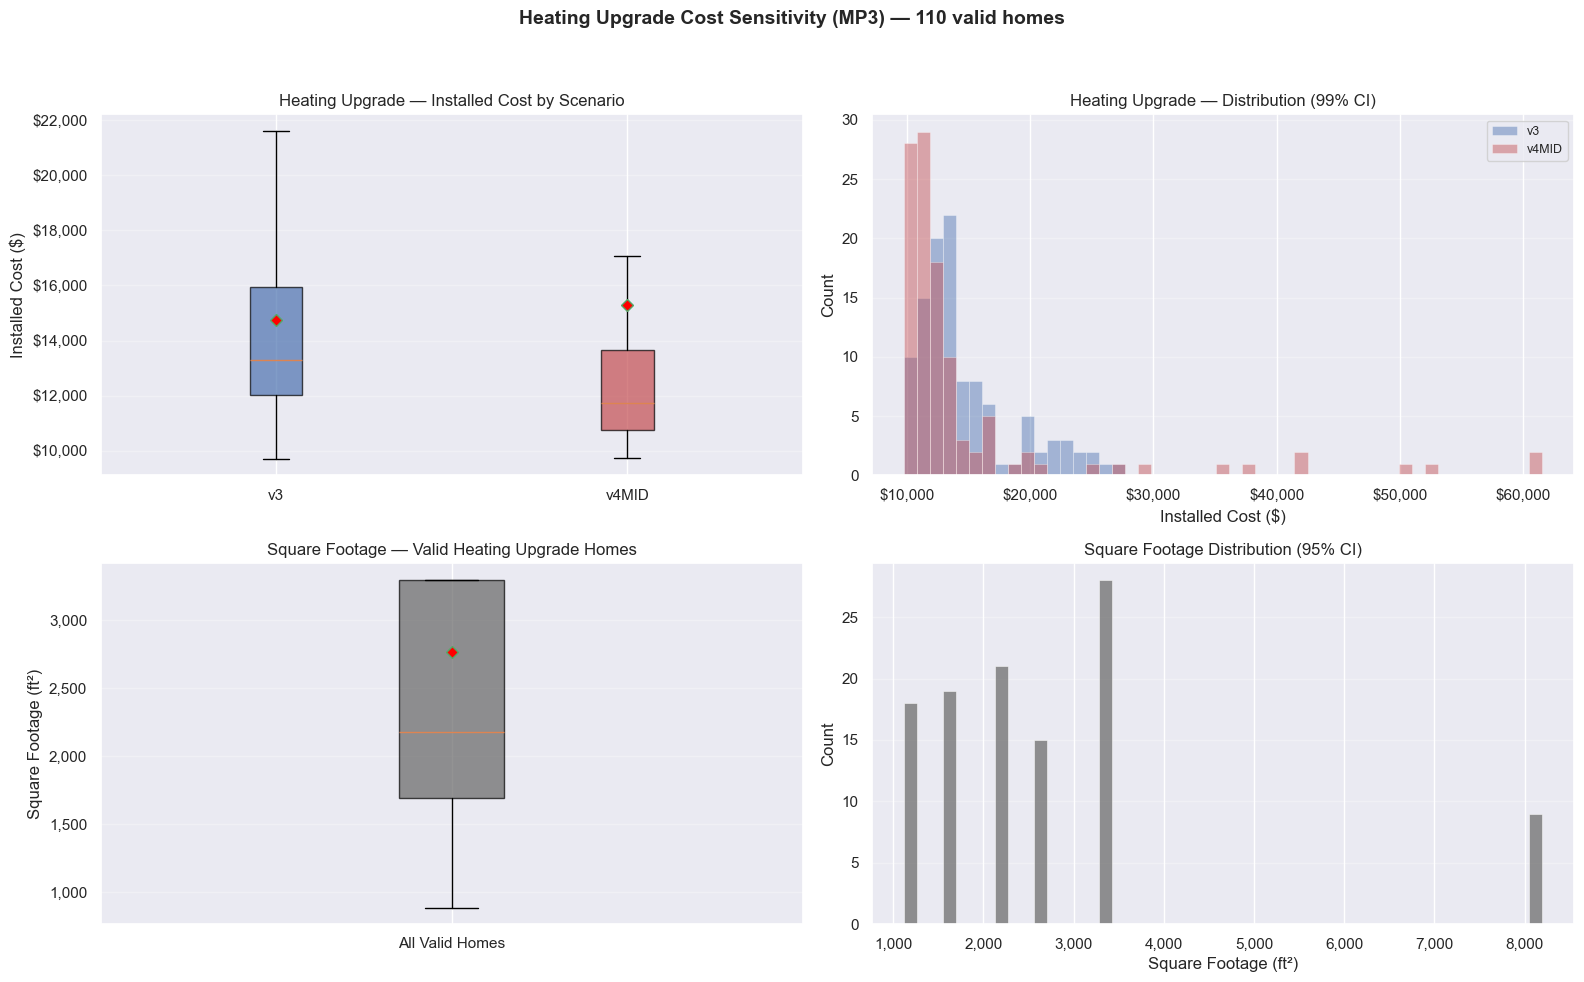

In [40]:
# =============================================================================
# TEST 3a: Heating Upgrade Visualization — 2×2 figure
# =============================================================================

if CAPITAL_COST_VALIDATION:


    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    # Dynamic color and label mapping keyed by cost scenario
    COLOR_MAP = {
        'v3':     '#4C72B0',
        'v4LOW':  '#55A868',
        'v4MID':  '#C44E52',
        'v4HIGH': '#8172B2',
    }
    SQFT_COLOR = '#666666'

    # Derive labels and colors from the ACTIVE cost scenarios
    ACTIVE_SCENARIO_LABELS = REMDB_COST_SCENARIO_KEYS  # Use actual keys as labels
    ACTIVE_COLORS = [COLOR_MAP.get(k, '#999999') for k in REMDB_COST_SCENARIO_KEYS]

    def dollar_formatter(x, _):
        return f"${x:,.0f}"

    def make_sensitivity_figure(category, cost_type, scenarios, scenario_labels, colors, df_src, menu_mp, location_id):
        """Create a 2×2 sensitivity figure for a given cost metric."""
        # Gather data
        cost_data = {}
        for scenario, label in zip(scenarios, scenario_labels):
            col = create_cost_col(menu_mp, category, cost_type, scenario)
            if col in df_src.columns:
                cost_data[label] = df_src[col].dropna()

        if not cost_data:
            print(f"  No valid columns found for {category} {cost_type} — skipping figure.")
            return None

        metric_label = f"{category.title()} {cost_type.title()}"
        n_valid = max(len(v) for v in cost_data.values())

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(
            f'{metric_label} Cost Sensitivity (MP{menu_mp}) — {n_valid:,} valid homes',
            fontsize=14, fontweight='bold', y=0.98
        )

        # --- Top-left: Cost Boxplot ---
        ax = axes[0, 0]
        box_data = [cost_data[lbl].values for lbl in scenario_labels if lbl in cost_data]
        box_labels = [lbl for lbl in scenario_labels if lbl in cost_data]
        bp = ax.boxplot(box_data, labels=box_labels, showfliers=False, patch_artist=True,
                        showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
        for patch, color in zip(bp['boxes'], colors[:len(box_data)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_formatter))
        ax.set_title(f'{metric_label} — Installed Cost by Scenario')
        ax.set_ylabel('Installed Cost ($)')
        ax.grid(axis='y', alpha=0.3)

        # --- Top-right: Cost Histogram (95% CI) ---
        ax = axes[0, 1]
        all_vals = pd.concat(cost_data.values())
        p005, p995 = all_vals.quantile(0.005), all_vals.quantile(0.995)
        bins = np.linspace(p005, p995, 50)
        for lbl, color in zip(scenario_labels, colors):
            if lbl in cost_data:
                ax.hist(cost_data[lbl].clip(lower=p005, upper=p995), bins=bins,
                        alpha=0.45, color=color, label=lbl, edgecolor='white', linewidth=0.5)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_formatter))
        ax.set_title(f'{metric_label} — Distribution (99% CI)')
        ax.set_xlabel('Installed Cost ($)')
        ax.set_ylabel('Count')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        # --- Bottom-left: Square Footage Boxplot ---
        ax = axes[1, 0]
        # Use homes that have at least one valid cost
        any_valid_col = next(
            (create_cost_col(menu_mp, category, cost_type, s)
            for s in scenarios if create_cost_col(menu_mp, category, cost_type, s) in df_src.columns),
            None
        )
        if any_valid_col and 'square_footage' in df_src.columns:
            sqft = df_src.loc[df_src[any_valid_col].notna(), 'square_footage'].dropna()
            bp2 = ax.boxplot([sqft.values], labels=['All Valid Homes'], showfliers=False,
                            patch_artist=True, showmeans=True,
                            meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
            bp2['boxes'][0].set_facecolor(SQFT_COLOR)
            bp2['boxes'][0].set_alpha(0.7)
            ax.set_title(f'Square Footage — Valid {metric_label} Homes')
            ax.set_ylabel('Square Footage (ft²)')
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        else:
            ax.text(0.5, 0.5, 'Square footage data not available', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11)
            ax.set_title('Square Footage — N/A')
        ax.grid(axis='y', alpha=0.3)

        # --- Bottom-right: Square Footage Histogram ---
        ax = axes[1, 1]
        if any_valid_col and 'square_footage' in df_src.columns:
            sqft = df_src.loc[df_src[any_valid_col].notna(), 'square_footage'].dropna()
            sq_p025, sq_p975 = sqft.quantile(0.025), sqft.quantile(0.975)
            sq_bins = np.linspace(sq_p025, sq_p975, 50)
            ax.hist(sqft.clip(lower=sq_p025, upper=sq_p975), bins=sq_bins,
                    alpha=0.7, color=SQFT_COLOR, edgecolor='white', linewidth=0.5)
            ax.set_title(f'Square Footage Distribution (95% CI)')
            ax.set_xlabel('Square Footage (ft²)')
            ax.set_ylabel('Count')
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        else:
            ax.text(0.5, 0.5, 'Square footage data not available', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11)
            ax.set_title('Square Footage Distribution — N/A')
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Save figure
        docs_dir = os.path.join(PROJECT_ROOT, 'cmu_tare_model', 'docs')
        os.makedirs(docs_dir, exist_ok=True)
        fig_path = os.path.join(docs_dir,
            f"capital_cost_sensitivity_{category}_{cost_type}_mp{menu_mp}_{location_id}.png")
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"  Saved: {fig_path}")
        plt.show()
        return fig_path

    # --- Heating Upgrade ---
    print("=" * 90)
    print("TEST 3a: Heating Upgrade Visualization")
    print(f"Active cost scenarios: {REMDB_COST_SCENARIO_KEYS}")
    print("=" * 90)

    heating_upgrade_fig = make_sensitivity_figure(
        category='heating', cost_type='upgrade',
        scenarios=REMDB_COST_SCENARIO_KEYS,
        scenario_labels=ACTIVE_SCENARIO_LABELS,
        colors=ACTIVE_COLORS,
        df_src=df, menu_mp=menu_mp, location_id=location_id
    )

TEST 3b: Heating Replacement Visualization
Active cost scenarios: ['v3', 'v4MID']


C:\Users\jorda\AppData\Local\Temp\ipykernel_42072\1425303853.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, showfliers=False, patch_artist=True,
C:\Users\jorda\AppData\Local\Temp\ipykernel_42072\1425303853.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot([sqft.values], labels=['All Valid Homes'], showfliers=False,


  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\docs\capital_cost_sensitivity_heating_replacement_mp3_Longmont.png


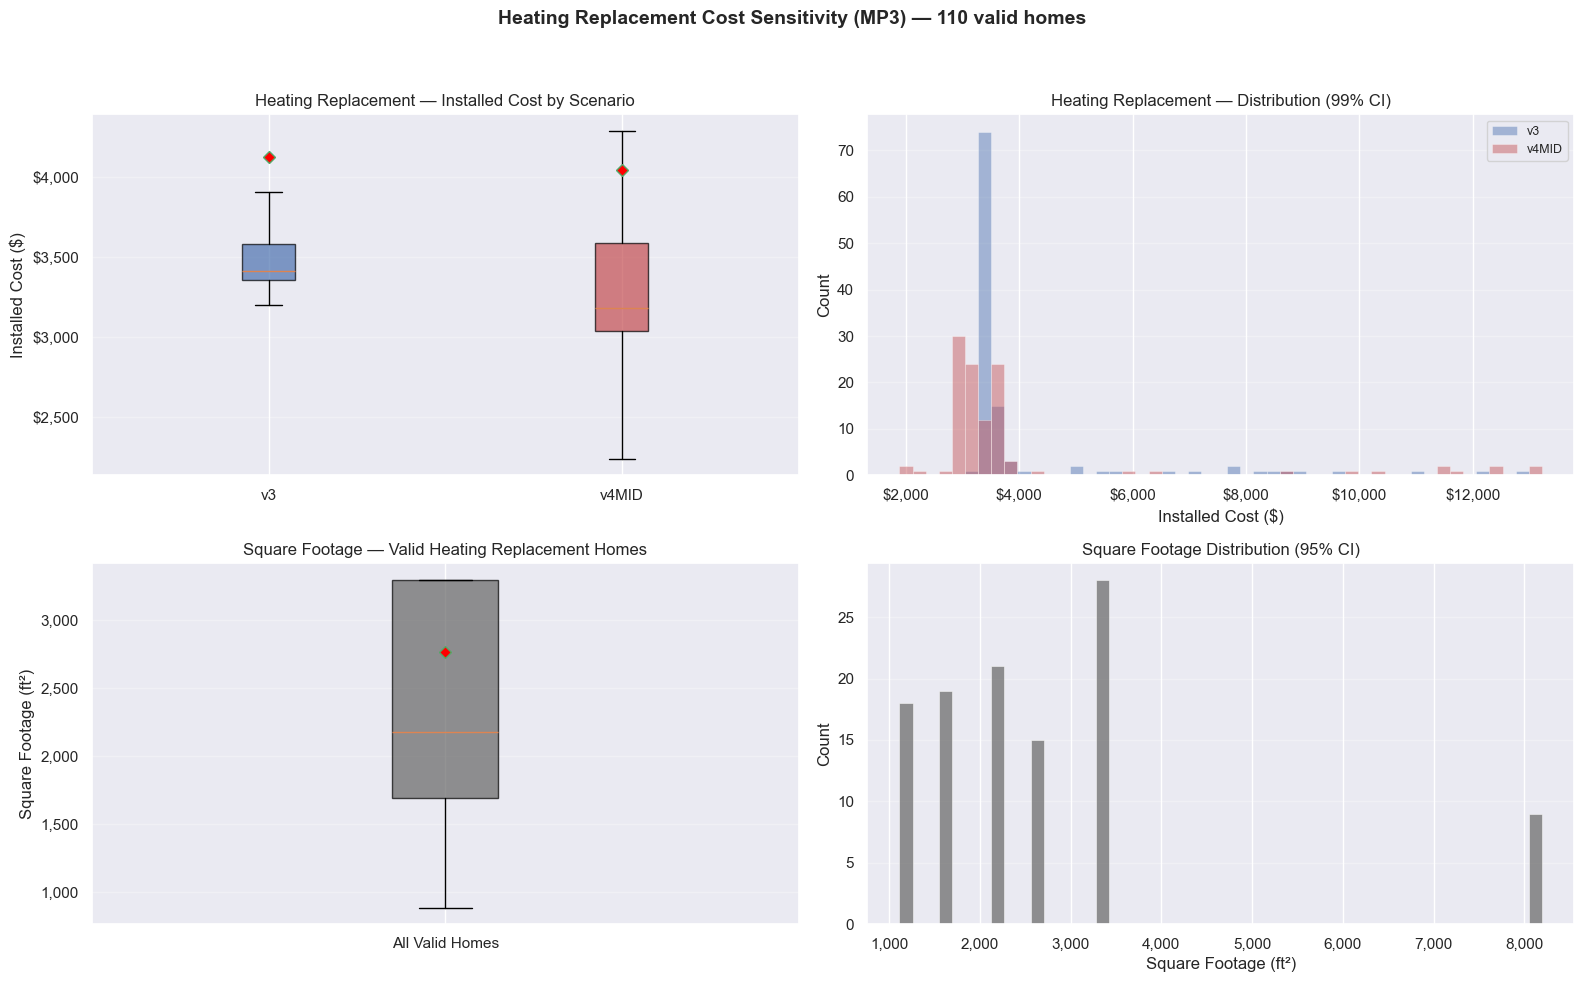

In [41]:
# =============================================================================
# TEST 3b: Heating Replacement Visualization — 2×2 figure
# =============================================================================

if CAPITAL_COST_VALIDATION:

    print("=" * 90)
    print("TEST 3b: Heating Replacement Visualization")
    print(f"Active cost scenarios: {REMDB_COST_SCENARIO_KEYS}")
    print("=" * 90)

    heating_replacement_fig = make_sensitivity_figure(
        category='heating', cost_type='replacement',
        scenarios=REMDB_COST_SCENARIO_KEYS,
        scenario_labels=ACTIVE_SCENARIO_LABELS,
        colors=ACTIVE_COLORS,
        df_src=df, menu_mp=menu_mp, location_id=location_id
    )

TEST 3c: Cooling Replacement Visualization (v4 only — no v3)
Active cooling scenarios: ['v4MID']


C:\Users\jorda\AppData\Local\Temp\ipykernel_42072\1425303853.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, showfliers=False, patch_artist=True,
C:\Users\jorda\AppData\Local\Temp\ipykernel_42072\1425303853.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot([sqft.values], labels=['All Valid Homes'], showfliers=False,


  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\docs\capital_cost_sensitivity_cooling_replacement_mp3_Longmont.png


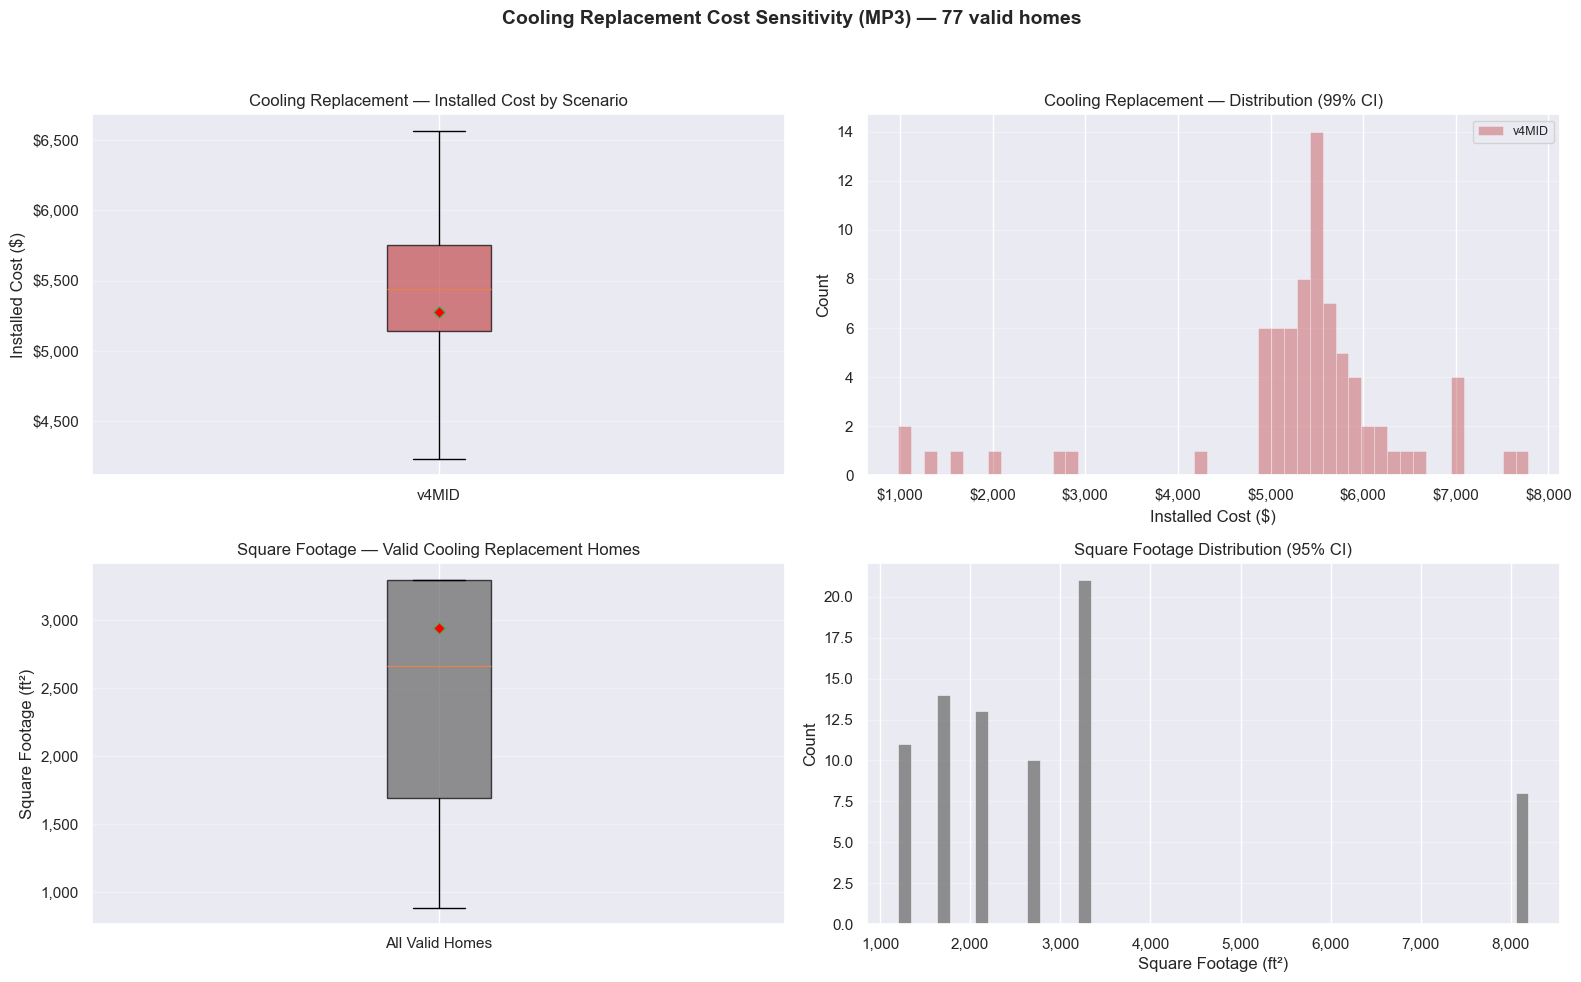

In [42]:
# =============================================================================
# TEST 3c: Cooling Replacement Visualization — 2×2 figure (v4 only, no v3)
# =============================================================================

if CAPITAL_COST_VALIDATION:

    COOLING_SCENARIOS = [k for k in REMDB_COST_SCENARIO_KEYS if k != 'v3']
    COOLING_LABELS = COOLING_SCENARIOS  # Use actual keys as labels
    COOLING_COLORS = [COLOR_MAP.get(k, '#999999') for k in COOLING_SCENARIOS]

    print("=" * 90)
    print("TEST 3c: Cooling Replacement Visualization (v4 only — no v3)")
    print(f"Active cooling scenarios: {COOLING_SCENARIOS}")
    print("=" * 90)

    if not COOLING_SCENARIOS:
        print("  No v4 cost scenarios active — skipping cooling visualization.")
    else:
        cooling_replacement_fig = make_sensitivity_figure(
            category='cooling', cost_type='replacement',
            scenarios=COOLING_SCENARIOS,
            scenario_labels=COOLING_LABELS,
            colors=COOLING_COLORS,
            df_src=df, menu_mp=menu_mp, location_id=location_id
        )

In [43]:
# =============================================================================
# TEST 4: NPV Consistency — Check capital cost + NPV columns in post-NPV DataFrames
# =============================================================================

if CAPITAL_COST_VALIDATION:

    from cmu_tare_model.utils.column_names import create_capital_col, create_npv_col

    print("=" * 90)
    print("TEST 4: NPV Consistency — Capital cost & NPV columns in post-NPV DataFrames")
    print("=" * 90)

    npv_ref_df = DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base'][RCM_MODELS[0]]
    print(f"Reference DataFrame: DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base']['{RCM_MODELS[0]}']")
    print(f"Shape: {npv_ref_df.shape}")

    # Determine policy prefixes from what's available
    # Try to detect prefixes by looking for columns matching pattern
    all_cols = list(npv_ref_df.columns)
    policy_prefixes = []
    for prefix_candidate in [f'preIRA_mp{menu_mp}_', f'iraRef_mp{menu_mp}_']:
        if any(c.startswith(prefix_candidate) for c in all_cols):
            policy_prefixes.append(prefix_candidate)

    if not policy_prefixes:
        # Fallback: try to find any prefix ending in _mp{menu_mp}_
        import re
        prefix_pattern = re.compile(rf'^(\w+_mp{menu_mp}_)')
        found_prefixes = set()
        for c in all_cols:
            m = prefix_pattern.match(c)
            if m:
                found_prefixes.add(m.group(1))
        policy_prefixes = sorted(found_prefixes)
        print(f"  Auto-detected prefixes: {policy_prefixes}")
    else:
        print(f"  Policy prefixes: {policy_prefixes}")

    npv_pass = True

    # The reference DataFrame is from 'fixed_base', so NPV columns carry the
    # '_fixed_base' method suffix.  Use that for v4MID lookups consistently.
    NPV_METHOD_SUFFIX = '_fixed_base'

    for prefix in policy_prefixes:
        policy_label = 'IRA' if 'iraRef' in prefix else 'No IRA' if 'preIRA' in prefix else prefix
        print(f"\n--- Policy: {policy_label} (prefix: {prefix}) ---")

        # Check capital cost columns (with v4MID suffix for v4)
        for net in [False, True]:
            kind = 'net' if net else 'total'
            col_mid = create_capital_col(scenario_prefix=prefix, category='heating', net=net, cost_scenario='v4MID')
            col_v3  = create_capital_col(scenario_prefix=prefix, category='heating', net=net, cost_scenario='v3')

            for col, label in [(col_v3, f'{kind} capital (v3)'), (col_mid, f'{kind} capital (v4MID)')]:
                if col in npv_ref_df.columns:
                    s = npv_ref_df[col].dropna()
                    print(f"  ✓ {label:<30} | N={len(s):>7,} | Mean=${s.mean():>10,.0f} | Median=${s.median():>10,.0f}")
                else:
                    print(f"  ✗ {label:<30} | Column '{col}' NOT FOUND")
                    npv_pass = False

        # Check NPV columns (lessWTP and moreWTP)
        for wtp in ['lessWTP', 'moreWTP']:
            # Check v4MID variant — NPV columns include the discount method suffix
            col_npv = create_npv_col(scenario_prefix=prefix, category='heating', wtp=wtp, cost_scenario='v4MID', method_suffix=NPV_METHOD_SUFFIX)
            if col_npv in npv_ref_df.columns:
                s = npv_ref_df[col_npv].dropna()
                print(f"  ✓ NPV {wtp} (v4MID){'':<10} | N={len(s):>7,} | Mean=${s.mean():>10,.0f} | Median=${s.median():>10,.0f}")
            else:
                print(f"  ✗ NPV {wtp} (v4MID){'':<10} | Column '{col_npv}' NOT FOUND")

            # Check v3 variant (uses method_suffix for discount rate method)
            col_npv_v3 = create_npv_col(scenario_prefix=prefix, category='heating', wtp=wtp, cost_scenario='v3', method_suffix=NPV_METHOD_SUFFIX)
            if col_npv_v3 in npv_ref_df.columns:
                s = npv_ref_df[col_npv_v3].dropna()
                print(f"  ✓ NPV {wtp} (v3/fixed){'':<8} | N={len(s):>7,} | Mean=${s.mean():>10,.0f} | Median=${s.median():>10,.0f}")

        # Check moreWTP ≥ lessWTP for v4MID
        col_less = create_npv_col(scenario_prefix=prefix, category='heating', wtp='lessWTP', cost_scenario='v4MID', method_suffix=NPV_METHOD_SUFFIX)
        col_more = create_npv_col(scenario_prefix=prefix, category='heating', wtp='moreWTP', cost_scenario='v4MID', method_suffix=NPV_METHOD_SUFFIX)
        if col_less in npv_ref_df.columns and col_more in npv_ref_df.columns:
            both = npv_ref_df[col_less].notna() & npv_ref_df[col_more].notna()
            violations = (npv_ref_df.loc[both, col_more] < npv_ref_df.loc[both, col_less]).sum()
            n_check = both.sum()
            if violations > 0:
                print(f"  ⚠ moreWTP < lessWTP in {violations:,} / {n_check:,} rows")
                npv_pass = False
            else:
                print(f"  ✓ moreWTP ≥ lessWTP in all {n_check:,} valid rows")

    print("\n" + "=" * 90)
    print(f"TEST 4 OVERALL: {'✓ ALL PASS' if npv_pass else '✗ SOME ISSUES — see above'}")
    print("=" * 90)

TEST 4: NPV Consistency — Capital cost & NPV columns in post-NPV DataFrames
Reference DataFrame: DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base']['ap2']
Shape: (114, 316)
  Policy prefixes: ['preIRA_mp3_', 'iraRef_mp3_']

--- Policy: No IRA (prefix: preIRA_mp3_) ---
  ✓ total capital (v3)             | N=    110 | Mean=$    14,737 | Median=$    13,280
  ✓ total capital (v4MID)          | N=    110 | Mean=$    15,273 | Median=$    11,727
  ✓ net capital (v3)               | N=    110 | Mean=$    10,614 | Median=$     9,700
  ✓ net capital (v4MID)            | N=    110 | Mean=$    11,230 | Median=$     8,546
  ✓ NPV lessWTP (v4MID)           | N=    110 | Mean=$   -11,669 | Median=$   -10,390
  ✓ NPV lessWTP (v3/fixed)         | N=    110 | Mean=$   -11,134 | Median=$   -11,550
  ✓ NPV moreWTP (v4MID)           | N=    110 | Mean=$    -7,626 | Median=$    -6,849
  ✓ NPV moreWTP (v3/fixed)         | N=    110 | Mean=$    -7,010 | Median=$    -7,985
  ✓ moreWTP ≥ lessWTP in all 110 valid ro

In [44]:
# =============================================================================
# TEST 5: Cost Scenario Column Propagation — Count scenario-suffixed columns
# =============================================================================

if CAPITAL_COST_VALIDATION:

    print("=" * 90)
    print("TEST 5: Cost Scenario Column Propagation")
    print(f"Active cost scenarios: {REMDB_COST_SCENARIO_KEYS}")
    print("=" * 90)

    # Build suffixes from active cost scenarios (e.g. '_v3', '_v4MID')
    active_suffixes = [f'_{cs}' for cs in REMDB_COST_SCENARIO_KEYS]

    scenario_cols_main = [c for c in df.columns if any(c.endswith(sfx) for sfx in active_suffixes)]
    print(f"\n1) df_euss_am_mpX_home:")
    print(f"   Total columns: {len(df.columns):,}")
    print(f"   Cost-scenario-suffixed columns: {len(scenario_cols_main)}")
    for sfx in active_suffixes:
        sfx_cols = [c for c in df.columns if c.endswith(sfx)]
        print(f"     {sfx}: {len(sfx_cols)} columns")
        if len(sfx_cols) <= 10:
            for c in sorted(sfx_cols):
                print(f"       - {c}")

    # Count scenario-suffixed columns in post-NPV reference DataFrame
    scenario_cols_npv = [c for c in npv_ref_df.columns if any(c.endswith(sfx) for sfx in active_suffixes)]
    print(f"\n2) DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base']['{RCM_MODELS[0]}']:")
    print(f"   Total columns: {len(npv_ref_df.columns):,}")
    print(f"   Cost-scenario-suffixed columns: {len(scenario_cols_npv)}")
    for sfx in active_suffixes:
        sfx_cols = [c for c in npv_ref_df.columns if c.endswith(sfx)]
        print(f"     {sfx}: {len(sfx_cols)} columns")
        if len(sfx_cols) <= 10:
            for c in sorted(sfx_cols):
                print(f"       - {c}")

    # Print CAPITAL_COSTS_MPX structure
    print(f"\n3) CAPITAL_COSTS_MPX structure:")
    for end_use in CAPITAL_COSTS_MPX:
        for cost_type in CAPITAL_COSTS_MPX[end_use]:
            keys = list(CAPITAL_COSTS_MPX[end_use][cost_type].keys())
            print(f"   {end_use}.{cost_type} → {keys}")

TEST 5: Cost Scenario Column Propagation
Active cost scenarios: ['v3', 'v4MID']

1) df_euss_am_mpX_home:
   Total columns: 149
   Cost-scenario-suffixed columns: 7
     _v3: 3 columns
       - mp3_heating_rebate_amount_v3
       - mp3_heating_replacement_installed_cost_v3
       - mp3_heating_upgrade_installed_cost_v3
     _v4MID: 4 columns
       - mp3_cooling_replacement_installed_cost_v4MID
       - mp3_heating_rebate_amount_v4MID
       - mp3_heating_replacement_installed_cost_v4MID
       - mp3_heating_upgrade_installed_cost_v4MID

2) DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base']['ap2']:
   Total columns: 316
   Cost-scenario-suffixed columns: 63
     _v3: 31 columns
     _v4MID: 32 columns

3) CAPITAL_COSTS_MPX structure:
   heating.replacement → ['v3', 'v4MID']
   heating.upgrade → ['v3', 'v4MID']


In [45]:
# =============================================================================
# TEST 6: Regional Disaggregation — cost by census_division_recs × scenario
# =============================================================================

if CAPITAL_COST_VALIDATION:

    print("=" * 90)
    print("TEST 6: Regional Disaggregation by Census Division")
    print("=" * 90)

    REGION_COL = 'census_division_recs'

    if REGION_COL not in df.columns:
        print(f"  Column '{REGION_COL}' not found — skipping regional disaggregation.")
    else:
        for category, cost_type, scenarios in COST_METRICS:
            metric_label = f"{category} {cost_type}"
            print(f"\n--- {metric_label.upper()} ---")

            regional_rows = []
            for scenario in scenarios:
                col = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario=scenario)
                scenario_label = scenario

                if col not in df.columns:
                    continue

                # Group by region
                for region, grp in df.groupby(REGION_COL):
                    series = grp[col].dropna()
                    if len(series) == 0:
                        continue
                    regional_rows.append({
                        'Region': region,
                        'Scenario': scenario_label,
                        'N': len(series),
                        'Mean': series.mean(),
                        'Median': series.median(),
                        'P10': series.quantile(0.10),
                        'P90': series.quantile(0.90),
                    })

            if regional_rows:
                df_regional = pd.DataFrame(regional_rows)
                # Format for display
                df_reg_display = df_regional.copy()
                df_reg_display['N'] = df_reg_display['N'].apply(lambda x: f"{x:,}")
                for c in ['Mean', 'Median', 'P10', 'P90']:
                    df_reg_display[c] = df_reg_display[c].apply(lambda x: f"${x:,.0f}")
                # Sort by region then scenario
                df_reg_display = df_reg_display.sort_values(['Region', 'Scenario'])
                print(f"\n{df_reg_display.to_string(index=False)}")
            else:
                print("  No valid data for regional breakdown.")

TEST 6: Regional Disaggregation by Census Division

--- HEATING UPGRADE ---

        Region Scenario   N    Mean  Median     P10     P90
Mountain North       v3 110 $14,737 $13,280 $11,182 $21,446
Mountain North    v4MID 110 $15,273 $11,727 $10,343 $21,670

--- HEATING REPLACEMENT ---

        Region Scenario   N   Mean Median    P10    P90
Mountain North       v3 110 $4,123 $3,411 $3,339 $6,759
Mountain North    v4MID 110 $4,043 $3,181 $2,989 $6,074

--- COOLING REPLACEMENT ---

        Region Scenario  N   Mean Median    P10    P90
Mountain North    v4MID 77 $5,277 $5,440 $4,637 $6,334


In [46]:
# =============================================================================
# TEST 7: Fuel Type Disaggregation — cost by base_heating_fuel × scenario
# =============================================================================

if CAPITAL_COST_VALIDATION:

    print("=" * 90)
    print("TEST 7: Fuel Type Disaggregation by Base Heating Fuel")
    print("=" * 90)

    FUEL_COL = 'base_heating_fuel'

    if FUEL_COL not in df.columns:
        print(f"  Column '{FUEL_COL}' not found — skipping fuel type disaggregation.")
    else:
        for category, cost_type, scenarios in COST_METRICS:
            metric_label = f"{category} {cost_type}"
            print(f"\n--- {metric_label.upper()} ---")

            if category == 'cooling':
                print("  Note: Cooling fuel is always Electricity. Disaggregating by base_heating_fuel")
                print("  as a proxy for home characteristics.")

            fuel_rows = []
            for scenario in scenarios:
                col = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario=scenario)
                scenario_label = scenario

                if col not in df.columns:
                    continue

                for fuel, grp in df.groupby(FUEL_COL):
                    series = grp[col].dropna()
                    if len(series) == 0:
                        continue
                    fuel_rows.append({
                        'Fuel': fuel,
                        'Scenario': scenario_label,
                        'N': len(series),
                        'Mean': series.mean(),
                        'Median': series.median(),
                        'P10': series.quantile(0.10),
                        'P90': series.quantile(0.90),
                    })

            if fuel_rows:
                df_fuel = pd.DataFrame(fuel_rows)
                df_fuel_display = df_fuel.copy()
                df_fuel_display['N'] = df_fuel_display['N'].apply(lambda x: f"{x:,}")
                for c in ['Mean', 'Median', 'P10', 'P90']:
                    df_fuel_display[c] = df_fuel_display[c].apply(lambda x: f"${x:,.0f}")
                df_fuel_display = df_fuel_display.sort_values(['Fuel', 'Scenario'])
                print(f"\n{df_fuel_display.to_string(index=False)}")
            else:
                print("  No valid data for fuel type breakdown.")

TEST 7: Fuel Type Disaggregation by Base Heating Fuel

--- HEATING UPGRADE ---

       Fuel Scenario  N    Mean  Median     P10     P90
Electricity       v3 17 $15,291 $14,430 $10,964 $23,777
Electricity    v4MID 17 $21,579 $12,339 $10,602 $50,269
Natural Gas       v3 90 $14,532 $13,185 $11,196 $20,684
Natural Gas    v4MID 90 $13,746 $11,659 $10,329 $16,759
    Propane       v3  3 $17,738 $14,263 $13,864 $23,002
    Propane    v4MID  3 $25,345 $12,375 $11,683 $44,194

--- HEATING REPLACEMENT ---

       Fuel Scenario  N   Mean Median    P10     P90
Electricity       v3 17 $7,601 $7,838 $3,694 $11,461
Electricity    v4MID 17 $8,287 $9,950 $2,084 $12,802
Natural Gas       v3 90 $3,428 $3,389 $3,338  $3,580
Natural Gas    v4MID 90 $3,267 $3,140 $2,993  $3,632
    Propane       v3  3 $5,276 $5,116 $5,090  $5,527
    Propane    v4MID  3 $3,288 $3,091 $3,051  $3,603

--- COOLING REPLACEMENT ---
  Note: Cooling fuel is always Electricity. Disaggregating by base_heating_fuel
  as a proxy for h

In [47]:
# =============================================================================
# TEST 8: Cooling Replacement Deep Dive — Row ID, Technology, and v4MID Validation
# =============================================================================
# Investigates cooling replacement costs:
# 1. What cooling types exist and how they map to row_ids
# 2. REMDB coefficient analysis per row_id
# 3. Magnitude comparison — cooling replacement vs heating upgrade/replacement
# =============================================================================

if CAPITAL_COST_VALIDATION:

    from cmu_tare_model.utils.remdb_v4_installed_cost_utils import load_remdb_v4_data

    print("=" * 90)
    print("TEST 8: Cooling Replacement Deep Dive (v4MID)")
    print("=" * 90)

    # --- Step 1: Cooling type distribution & row_id mapping ---
    print("\n--- Step 1: Cooling Type Distribution & Row ID Mapping ---")

    if 'hvac_cooling_type' in df.columns:
        print("\n  hvac_cooling_type value counts:")
        cool_type_counts = df['hvac_cooling_type'].value_counts(dropna=False)
        for val, cnt in cool_type_counts.items():
            print(f"    {val}: {cnt:,}")

    if 'hvac_has_ducts' in df.columns:
        print("\n  hvac_has_ducts value counts:")
        duct_counts = df['hvac_has_ducts'].value_counts(dropna=False)
        for val, cnt in duct_counts.items():
            print(f"    {val}: {cnt:,}")

    # Check row_id assignment from the detailed DataFrame
    df_v4mid_source = CAPITAL_COSTS_MPX['heating']['upgrade'].get('v4MID')
    if df_v4mid_source is not None and 'row_id_cooling_replacement' in df_v4mid_source.columns:
        print("\n  row_id_cooling_replacement distribution:")
        row_id_counts = df_v4mid_source['row_id_cooling_replacement'].value_counts(dropna=False)
        for val, cnt in row_id_counts.items():
            print(f"    {val}: {cnt:,}")
    else:
        print("\n  row_id_cooling_replacement not found in v4MID source DataFrame")

    # --- Step 2: REMDB v4 coefficient analysis for cooling row_ids ---
    print("\n--- Step 2: REMDB v4 Coefficient Analysis for Cooling ---")

    remdb_data = load_remdb_v4_data()
    cooling_row_ids = [
        'air_conditioner_room_ac_window_or_through_wall',
        'air_conditioner_centrally_ducted',
        'air_source_heat_pump_centrally_ducted',
        'air_source_heat_pump_non_ducted_multi_zone',
    ]

    for row_id in cooling_row_ids:
        if row_id not in remdb_data.index:
            print(f"\n  {row_id}: NOT FOUND in REMDB data")
            continue

        row = remdb_data.loc[row_id]
        print(f"\n  {row_id}:")
        print(f"    pm1: {row['pm1_metric']} ({row['pm1_unit']})")
        print(f"      mid coef: {row['pm1_coef_mid']:.4f}")
        print(f"    pm2: {row['pm2_metric']} ({row['pm2_unit']})")
        print(f"      mid coef: {row['pm2_coef_mid']:.4f}")
        print(f"    intercept_mid: {row['intercept_mid']:.2f}")
        print(f"    multiplier_retrofit={row['multiplier_retrofit']}, adder_retrofit={row['adder_retrofit']:.2f}")

    # --- Step 3: Per-row_id cost statistics (v4MID only) ---
    print("\n--- Step 3: Per-Row-ID Cost Statistics (v4MID) ---")

    cool_col_mid = create_cost_col(menu_mp=menu_mp, category='cooling', cost_type='replacement', cost_scenario='v4MID')

    if cool_col_mid not in df.columns:
        print(f"  Column '{cool_col_mid}' not found — skipping.")
    elif df_v4mid_source is not None and 'row_id_cooling_replacement' in df_v4mid_source.columns:
        df_cool_analysis = df.copy()
        df_cool_analysis['row_id_cooling_replacement'] = df_v4mid_source['row_id_cooling_replacement'].values

        for row_id in df_cool_analysis['row_id_cooling_replacement'].unique():
            if pd.isna(row_id) or row_id == 'unknown':
                continue
            mask = df_cool_analysis['row_id_cooling_replacement'] == row_id
            s = df_cool_analysis.loc[mask, cool_col_mid].dropna()
            if len(s) > 0:
                print(f"\n  {row_id} (N={mask.sum():,}):")
                print(f"    v4MID: Mean=${s.mean():>10,.0f}  Median=${s.median():>10,.0f}  "
                    f"P5=${s.quantile(0.05):>10,.0f}  P95=${s.quantile(0.95):>10,.0f}")

    # --- Step 4: Magnitude comparison — cooling replacement vs heating upgrade/replacement ---
    print("\n--- Step 4: Magnitude Comparison (v4MID) ---")

    heat_upgr_col = create_cost_col(menu_mp=menu_mp, category='heating', cost_type='upgrade', cost_scenario='v4MID')
    cool_repl_col = create_cost_col(menu_mp=menu_mp, category='cooling', cost_type='replacement', cost_scenario='v4MID')
    heat_repl_col = create_cost_col(menu_mp=menu_mp, category='heating', cost_type='replacement', cost_scenario='v4MID')

    for label, col in [('Heating Upgrade (v4MID)', heat_upgr_col),
                        ('Heating Replacement (v4MID)', heat_repl_col),
                        ('Cooling Replacement (v4MID)', cool_repl_col)]:
        if col in df.columns:
            s = df[col].dropna()
            print(f"  {label:<35} N={len(s):>7,}  Mean=${s.mean():>10,.0f}  Median=${s.median():>10,.0f}")
        else:
            print(f"  {label:<35} Column not found")

    print("\n" + "=" * 90)
    print("TEST 8 COMPLETE")
    print("=" * 90)

TEST 8: Cooling Replacement Deep Dive (v4MID)

--- Step 1: Cooling Type Distribution & Row ID Mapping ---

  hvac_cooling_type value counts:
    Central AC: 68
    nan: 30
    Room AC: 9
    Heat Pump: 7

  hvac_has_ducts value counts:
    Yes: 98
    No: 16

  row_id_cooling_replacement distribution:
    air_conditioner_centrally_ducted: 68
    unknown: 30
    air_conditioner_room_ac_window_or_through_wall: 9
    air_source_heat_pump_centrally_ducted: 7

--- Step 2: REMDB v4 Coefficient Analysis for Cooling ---

  air_conditioner_room_ac_window_or_through_wall:
    pm1: Capacity (Tons)
      mid coef: 364.3320
    pm2: CEER (Unitless)
      mid coef: 6.0694
    intercept_mid: 13.28
    multiplier_retrofit=1.0, adder_retrofit=352.61

  air_conditioner_centrally_ducted:
    pm1: Cooling Capacity (Tons)
      mid coef: 328.2768
    pm2: SEER1 (Unitless)
      mid coef: 594.7400
    intercept_mid: -5888.94
    multiplier_retrofit=1.5, adder_retrofit=0.00

  air_source_heat_pump_centrally_

In [48]:
# =============================================================================
# TEST 9: Equipment-Level Capital Cost Disaggregation
# =============================================================================
# Validates installed costs disaggregated by equipment type, SEER/AFUE, 
# capacity, and fuel type. Reports P10/P50/P90 for each cost scenario.
#
# Binning approach (floor-based rounding):
#   Capacity: 1.5→2.4 = 2 tons, 2.5→3.4 = 3 tons, ... up to 10 tons
#   SEER: 12.5→13.4 = 13, 13.5→14.4 = 14, ... up to 25
#   AFUE: 77.5→78.4 = 78, 78.5→79.4 = 79, ... up to 98
#   kBTU/h: 35→44 = 40, 45→54 = 50, ... up to 200
# Outlier counts reported for homes outside bin ranges.
#
# Equipment types to compare in Trane data:
#   - ASHP (heating replacement): SEER {15,16,18,19,21} × {2,3,4,5} tons
#   - Central AC (cooling replacement): SEER {15,16,18,19,21} × {2,3,4,5} tons
#   - Gas Furnace (heating replacement): AFUE {80,96} × {80,120} kBTU/h
#   - Propane Furnace (heating replacement): AFUE {80,96} × {80,120} kBTU/h
# =============================================================================

if CAPITAL_COST_VALIDATION:
        
    import importlib
    import cmu_tare_model.utils.validate_capital_costs as vcv
    importlib.reload(vcv)
    from cmu_tare_model.utils.validate_capital_costs import run_capital_cost_validation

    validation_results = run_capital_cost_validation(
        df=df_euss_am_mpX_home,
        menu_mp=menu_mp,
        capital_costs_mpx=CAPITAL_COSTS_MPX,
        cost_scenarios=list(REMDB_COST_SCENARIO_KEYS),
    )


##############################################################################################################
#  CAPITAL COST VALIDATION: Equipment-Level Disaggregation (MP3)
#  Active cost scenarios: ['v3', 'v4MID']
#  Total homes in DataFrame: 114
##############################################################################################################

  ASHP — Air Source Heat Pump (Heating Replacement, Centrally Ducted)
  Cost type: heating replacement (like-for-like ASHP)
  Filter: heating_type = Electricity ASHP, hvac_has_ducts = Yes
  SEER bins: heating_replacement_pm2_euss (floored efficiency, see clamping summary)
  Costs: computed using floored efficiency (see Section 5 of protocol)

  Total homes matching filter: 7
  Outliers excluded from bins:
    Capacity  < 1.5 tons: 2 homes
    Capacity >= 10.5 tons: 0 homes
    SEER  < 12.5: 0 homes
    SEER >= 30.5: 0 homes

  Efficiency floor impact on SEER 15 bin composition (7 homes in bin):
    13 SEER (5 / 7 homes, 71.4%) -

In [49]:
# =============================================================================
# Per-Scenario Summary + Saved Figures
# =============================================================================

if CAPITAL_COST_VALIDATION:
        
    print("=" * 90)
    print("SENSITIVITY ANALYSIS SUMMARY")
    print("=" * 90)

    # Compact one-line-per-scenario-per-metric summary
    print(f"\nModel: MP{menu_mp}  |  Location: {location_id}  |  Total homes: {len(df):,}")
    print(f"\n{'Metric':<25} {'Scenario':<12} {'N Valid':>10} {'Mean':>14} {'Median':>14}")
    print(f"{'─'*25} {'─'*12} {'─'*10} {'─'*14} {'─'*14}")

    for category, cost_type, scenarios in COST_METRICS:
        metric_label = f"{category} {cost_type}"
        for scenario in scenarios:
            col = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario=scenario)
            scenario_label = scenario
            if col not in df.columns:
                print(f"{metric_label:<25} {scenario_label:<12} {'N/A':>10} {'N/A':>14} {'N/A':>14}")
                continue
            series = df[col].dropna()
            print(f"{metric_label:<25} {scenario_label:<12} {len(series):>10,} "
                f"${series.mean():>13,.0f} ${series.median():>13,.0f}")

    # Print saved figure paths
    print(f"\n{'─'*90}")
    print("Saved Figures:")
    docs_dir = os.path.join(PROJECT_ROOT, 'cmu_tare_model', 'docs')
    fig_names = [
        f"capital_cost_sensitivity_heating_upgrade_mp{menu_mp}_{location_id}.png",
        f"capital_cost_sensitivity_heating_replacement_mp{menu_mp}_{location_id}.png",
        f"capital_cost_sensitivity_cooling_replacement_mp{menu_mp}_{location_id}.png",
    ]
    for fn in fig_names:
        path = os.path.join(docs_dir, fn)
        exists = os.path.isfile(path)
        status = '✓' if exists else '✗ not found'
        print(f"  {status}  {path}")

    # Valid counts per metric
    print(f"\nValid Home Counts:")
    for category, cost_type, scenarios in COST_METRICS:
        metric_label = f"{category} {cost_type}"
        # Use first available column
        for scenario in scenarios:
            col = create_cost_col(menu_mp=menu_mp, category=category, cost_type=cost_type, cost_scenario=scenario)
            if col in df.columns:
                n_valid = df[col].notna().sum()
                print(f"  {metric_label}: {n_valid:,} valid homes (using {scenario})")
                break

    print(f"\n{'='*90}")
    print("Sensitivity analysis complete.")
    print(f"{'='*90}")

SENSITIVITY ANALYSIS SUMMARY

Model: MP3  |  Location: Longmont  |  Total homes: 114

Metric                    Scenario        N Valid           Mean         Median
───────────────────────── ──────────── ────────── ────────────── ──────────────
heating upgrade           v3                  110 $       14,737 $       13,280
heating upgrade           v4MID               110 $       15,273 $       11,727
heating replacement       v3                  110 $        4,123 $        3,411
heating replacement       v4MID               110 $        4,043 $        3,181
cooling replacement       v4MID                77 $        5,277 $        5,440

──────────────────────────────────────────────────────────────────────────────────────────
Saved Figures:
  ✓  c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\docs\capital_cost_sensitivity_heating_upgrade_mp3_Longmont.png
  ✓  c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\docs\capital_cost_sensitivity_heating_replacement_

# Tracing through TARE outputs for selected homes

## The cells below are setup for post-processing
Please note that the most efficient way to go about checking intermediate results is to add print statements to the imported files function of interest. This can be done using the following prompt:



In [ ]:
# The dataframes are stored in DATAFRAMES_MPX_RCM_DISCOUNT_RATE, keyed by discount rate method and RCM model.  
# For example, the dataframe for inmap model with fixed_base discount rate method: DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base']['inmap']  
# The variable df_euss_am_mpX_home stores results up to (and including) the capital cost calculations and rebate amounts
# df_euss_am_mpX_home therefore does not include public or private NPV columns or the adoption decision columns
df_test_mpx_costs = df_euss_am_mpX_home.copy()
df_test_mpx_results = DATAFRAMES_MPX_RCM_DISCOUNT_RATE['fixed_base']['inmap']

print(f"""
--------------------------------------------------------------------------
DataFrame for capital cost validation (up to capital costs, no NPV): 
--------------------------------------------------------------------------

{df_test_mpx_costs}

--------------------------------------------------------------------------
DataFrame with all results:
--------------------------------------------------------------------------

{df_test_mpx_results}
""")


--------------------------------------------------------------------------
DataFrame for capital cost validation (up to capital costs, no NPV): 
--------------------------------------------------------------------------

         square_footage census_region census_division census_division_recs  \
bldg_id                                                                      
5839             1220.0          West        Mountain       Mountain North   
7773             2663.0          West        Mountain       Mountain North   
10286            2176.0          West        Mountain       Mountain North   
13952            2176.0          West        Mountain       Mountain North   
25312            3301.0          West        Mountain       Mountain North   
...                 ...           ...             ...                  ...   
528852           1220.0          West        Mountain       Mountain North   
535777           2663.0          West        Mountain       Mountain North  

In [68]:
# Building IDs for debugging. (e.g., Longmont, CO: 32207, 7773, 10286, 13952)
DEBUG_IDS = [32207, 7773, 10286, 13952]

df_test_ids_mpx_results = df_test_mpx_results.copy()
df_test_ids_mpx_results = df_test_ids_mpx_results.loc[df_test_ids_mpx_results.index.isin(DEBUG_IDS)]

print(f"""
BUILDING IDS FOR DEBUGGING: {DEBUG_IDS}

--------------------------------------------------------------------------
DataFrame with all results filtered to building IDs for debugging:
--------------------------------------------------------------------------

{df_test_ids_mpx_results}
""")



BUILDING IDS FOR DEBUGGING: [32207, 7773, 10286, 13952]

--------------------------------------------------------------------------
DataFrame with all results filtered to building IDs for debugging:
--------------------------------------------------------------------------

         square_footage census_region census_division census_division_recs  \
bldg_id                                                                      
7773             2663.0          West        Mountain       Mountain North   
10286            2176.0          West        Mountain       Mountain North   
13952            2176.0          West        Mountain       Mountain North   
32207            3301.0          West        Mountain       Mountain North   

        building_america_climate_zone  reeds_balancing_area gea_region state  \
bldg_id                                                                        
7773                             Cold                    33      RMPAc    CO   
10286          

In [71]:
# Print list of columns in the filtered DataFrame to confirm presence of key columns for debugging
print(f"Columns in the filtered DataFrame: {df_test_ids_mpx_results.columns.tolist()}")

# Confirm the three baseline columns Tamar already has
cols_to_show = [
    "square_footage",
    "heating_type",
    "baseline_heating_consumption",
    # ... add more columns of interest here as needed
]

print(f"\nAttempting to show columns: {cols_to_show}")

df_test_ids_mpX = df_test_ids_mpx_results.loc[
    df_test_ids_mpx_results.index.isin(DEBUG_IDS),
    [col for col in cols_to_show if col in df_test_ids_mpx_results.columns]
].copy()

# If any column was missing, this will show you what's actually available
missing = [col for col in cols_to_show if col not in df_test_ids_mpx_results.columns]
if missing:
    print(f"\nColumns not found — searching for close matches:")
    for m in missing:
        keyword = m.split("_")[1]  # e.g. "heating" from "baseline_heating_consumption"
        matches = [col for col in df_test_ids_mpx_results.columns if keyword in col.lower()]
        print(f"  '{m}' → possible matches: {matches[:5]}")


Columns in the filtered DataFrame: ['square_footage', 'census_region', 'census_division', 'census_division_recs', 'building_america_climate_zone', 'reeds_balancing_area', 'gea_region', 'state', 'city', 'urbanicity', 'county', 'county_fips', 'puma', 'county_and_puma', 'weather_file_city', 'Longitude', 'Latitude', 'building_type', 'income', 'federal_poverty_level', 'occupancy', 'tenure', 'vacancy_status', 'vintage', 'base_heating_fuel', 'heating_type', 'base_heating_efficiency', 'base_electricity_heating_consumption', 'base_fuelOil_heating_consumption', 'base_naturalGas_heating_consumption', 'base_propane_heating_consumption', 'base_cooling_fuel', 'cooling_type', 'base_cooling_efficiency', 'base_electricity_cooling_consumption', 'baseline_heating_consumption', 'include_all', 'valid_fuel_heating', 'valid_tech_heating', 'include_heating', 'baseline_heating_lifetime_mt_co2e_lrmer', 'baseline_heating_lifetime_damages_climate_lrmer_lower', 'baseline_heating_lifetime_damages_climate_lrmer_cent